# 07 Customer Lifetime Value (CLV) Prediction - Customer Lifetime Value Prediction

## Project Overview

Customer Lifetime Value (CLV) prediction aims to estimate how much value each customer may generate for the business in a future period. This part is important because CLV is not only a modeling target, but also a core business metric for customer management, budget allocation, retention prioritization, and long-term growth planning. In this section, we first clarify the business objective of the project, define what CLV means in this notebook, summarize the main business value and technical challenges, and explain what outputs this project is expected to deliver. This gives a clear foundation before moving into data preparation, feature engineering, modeling, and strategy design.

## Project Objectives

This project aims to predict each customer's future value contribution and support the following business decisions:

1. Identify high-value, medium-value, and low-value customers
2. Optimize marketing budget allocation for higher ROI
3. Evaluate whether customer acquisition cost is reasonable
4. Identify VIP customers and support personalized service
5. Combine CLV with churn risk for value-risk management

## Business Value

- A small group of top customers may contribute a large share of total revenue
- Marketing resources can be allocated more efficiently
- High-CLV customers can receive stronger retention support
- CLV can be combined with churn prediction to guide intervention priority

## Technical Challenges

1. Choosing a suitable CLV definition
2. Designing training and prediction time windows
3. Building features from multiple data sources
4. Selecting suitable regression models
5. Evaluating both model accuracy and business usefulness

## Key Outputs

- Predicted CLV score for each customer
- Customer value tiers such as Platinum, Gold, Silver, and Bronze
- Value-risk matrix based on CLV and churn probability
- Budget allocation suggestions for different customer groups
- High-value customer list and customer profile analysis

# 1. CLV Foundation and Metric Definition

In this part, I define what Customer Lifetime Value means in this project and explain how the prediction target is constructed. This section is necessary because CLV can be measured in different ways, and the model result is only meaningful when the business definition is clear. Here, we briefly compare several common CLV methods, explain why this project uses future GMV as the target, and define both the regression and business evaluation metrics for later model assessment.

## 1.1 Overview of CLV Calculation Methods

There are several common ways to calculate CLV, and each method fits a different business scenario.

**Method 1: Historical CLV**

```text
Historical CLV = Total historical customer spending - Total cost
Simplified version:
Historical CLV = Σ(Order Value) - Σ(Customer Acquisition Cost + Service Cost)
```

**Method 2: Predictive CLV**

```text
Predictive CLV = Σ(Expected profit in future periods) × Retention probability
Classic formula:
CLV = (ARPU × Gross Margin) × (1 / Churn Rate)
```
**Method 3: Simplified RFM-based CLV**

```text
Simplified CLV = Average Order Value × Purchase Frequency × Customer Lifetime
               = Monetary × Frequency × (1 / Recency decay factor)
```

## 1.2 CLV Definition Used in This Project

In this project, the target variable is defined as future 6-month GMV.

This definition is chosen for three main reasons:

- The data is available from historical order records
- The target is easy to explain in business terms
- It can be combined with churn prediction for value-risk analysis

**Label Construction Logic**

```text
Training set:
Use customer behavior in T0-T1 to predict GMV in T1-T2

Example window design
Feature window: 2017-01-01 to 2017-06-30
Label window:   2017-07-01 to 2017-12-31

If data allows, a later rolling window can also be tested
Example:
Feature window: 2017-07-01 to 2017-12-31
Label window:   2018-01-01 to 2018-06-30
```

This means the model learns from past customer behavior and predicts the value generated in the next period, rather than describing historical spending only.

## 1.3 Evaluation Metric Design

To evaluate model performance, this project uses both regression metrics and business metrics.

**Regression Metrics**

- MAE (Mean Absolute Error): average absolute prediction error
- RMSE (Root Mean Squared Error): penalizes large errors more strongly
- MAPE (Mean Absolute Percentage Error): relative prediction error in percentage terms
- R² Score: overall goodness of fit

**Business Metrics**

- Top 10% CLV identification accuracy
- Tier consistency between predicted and actual customer value groups
- Segment-level MAPE across different value ranges

This metric design is important because a model with acceptable regression error may still perform poorly in customer ranking or customer tier assignment.

# 2 Data Preparation and Data Loading

This section prepares the project for modeling by setting up the notebook environment, loading the required data, and conducting an initial data check. This part is necessary because CLV prediction depends on reliable feature tables, correct target labels, and consistent data structure. In this section, we import the main libraries, connect to the database, load feature and label data, and perform an initial exploration of dataset size, missing values, and target availability.

## 2.1 Environment Setup, Data Loading, and Initial Exploration

Before feature engineering and model training, the notebook must first load the required libraries and retrieve the prepared data from the database. In this subsection, we set up the analysis environment, connect to the data warehouse, load the historical feature view and future GMV label view, merge them into one modeling table, and run several basic checks to understand the dataset structure.

In [1]:
# 2.1.1 Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime, timedelta

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 2.1.2 Connect to database
from src.utils.db import get_engine

engine = get_engine()
print("Database connection created successfully.")

Database connection created successfully.


In [3]:
# 2.1.2A Define snapshot window
FEATURE_END = pd.Timestamp('2017-06-30')
LABEL_START = pd.Timestamp('2017-07-01')
LABEL_END = pd.Timestamp('2017-12-31')

assert LABEL_START == FEATURE_END + pd.Timedelta(days=1)

print("Feature window end:", FEATURE_END.date())
print("Label window start:", LABEL_START.date())
print("Label window end:", LABEL_END.date())

Feature window end: 2017-06-30
Label window start: 2017-07-01
Label window end: 2017-12-31


In [4]:
# 2.1.3 Load prepared feature view
FEATURE_END = '2017-06-30'
LABEL_START = '2017-07-01'
LABEL_END = '2017-12-31'

sql_features = f"""
SELECT *
FROM view_user_clv_features
WHERE first_order_date < '{LABEL_START}'
  AND last_order_date <= '{FEATURE_END}'
"""

df_features = pd.read_sql(sql_features, engine)

print("Feature dataset loaded.")
print(f"df_features shape: {df_features.shape}")
df_features.head()

Feature dataset loaded.
df_features shape: (13367, 18)


,customer_unique_id,total_orders,total_gmv,avg_order_value,first_order_date,last_order_date,customer_lifetime_days,days_since_last_order,monthly_frequency,unique_products_purchased,unique_categories_purchased,avg_payment_value,max_installments_used,avg_review_score,satisfaction_rate,bad_review_count,avg_delivery_delay,delay_rate
0,0000f46a3911fa3c0805444483337064,1,86.22,86.22,2017-03-10 21:05:03,2017-03-10 21:05:03,0,3314,30.0,1,1,86.22,8.0,3.0,0.0,0.0,-2.0,0.0
1,0005e1862207bf6ccc02e4228effd9a0,1,150.12,150.12,2017-03-04 23:32:12,2017-03-04 23:32:12,0,3320,30.0,1,1,150.12,3.0,4.0,1.0,0.0,-28.0,0.0
2,00115fc7123b5310cf6d3a3aa932699e,1,76.11,76.11,2017-01-21 21:58:35,2017-01-21 21:58:35,0,3362,30.0,1,1,76.11,1.0,4.0,1.0,0.0,-33.0,0.0
3,0011805441c0d1b68b48002f1d005526,1,297.14,297.14,2017-04-24 13:36:48,2017-04-24 13:36:48,0,3269,30.0,1,1,297.14,10.0,3.0,0.0,0.0,-13.0,0.0
4,0011857aff0e5871ce5eb429f21cdaf5,1,192.83,192.83,2017-06-28 11:08:38,2017-06-28 11:08:38,0,3204,30.0,1,1,192.83,3.0,5.0,1.0,0.0,-20.0,0.0


In [5]:
sql_labels = """
SELECT *
FROM view_user_future_gmv
"""
df_labels = pd.read_sql(sql_labels, engine)

print(df_labels.shape)
df_labels.head()

(93358, 4)


,customer_unique_id,future_6m_gmv,future_6m_orders,is_active_future
0,0000366f3b9a7992bf8c76cfdf3221e2,0.00,0,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0.00,0,0
2,0000f46a3911fa3c0805444483337064,0.00,0,0
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,1,1
4,0004aac84e0df4da2b147fca70cf8255,196.89,1,1


In [49]:
print("Label columns:")
print(df_labels.columns.tolist())

label_check_cols = [
    col for col in [
        'customer_unique_id',
        'future_6m_gmv',
        'future_6m_orders',
        'is_active_future'
    ] if col in df_labels.columns
]

print("\nLabel preview:")
print(df_labels[label_check_cols].head())

print("\nLabel summary:")
print(df_labels[[col for col in ['future_6m_gmv', 'future_6m_orders', 'is_active_future'] if col in df_labels.columns]].describe())

print("\nPositive future GMV count in labels:", (df_labels['future_6m_gmv'] > 0).sum())
print("Positive future GMV rate in labels:", (df_labels['future_6m_gmv'] > 0).mean())
print("Max future GMV in labels:", df_labels['future_6m_gmv'].max())

Label columns:
['customer_unique_id', 'future_6m_gmv', 'future_6m_orders', 'is_active_future']

Label preview:
                 customer_unique_id  future_6m_gmv  future_6m_orders  \
0  0000366f3b9a7992bf8c76cfdf3221e2           0.00                 0   
1  0000b849f77a49e4a4ce2b2a4ca5be3f           0.00                 0   
2  0000f46a3911fa3c0805444483337064           0.00                 0   
3  0000f6ccb0745a6a4b88665a16c9f078          43.62                 1   
4  0004aac84e0df4da2b147fca70cf8255         196.89                 1   

   is_active_future  
0                 0  
1                 0  
2                 0  
3                 1  
4                 1  

Label summary:
       future_6m_gmv  future_6m_orders  is_active_future
count   93358.000000      93358.000000      93358.000000
mean       49.923611          0.315934          0.308061
std       142.760324          0.483525          0.461695
min         0.000000          0.000000          0.000000
25%         0.000000   

In [6]:
df = df_features.merge(df_labels, on='customer_unique_id', how='inner')
print(df.shape)
df.head()

(13367, 21)


,customer_unique_id,total_orders,total_gmv,avg_order_value,first_order_date,last_order_date,customer_lifetime_days,days_since_last_order,monthly_frequency,unique_products_purchased,...,avg_payment_value,max_installments_used,avg_review_score,satisfaction_rate,bad_review_count,avg_delivery_delay,delay_rate,future_6m_gmv,future_6m_orders,is_active_future
0,0000f46a3911fa3c0805444483337064,1,86.22,86.22,2017-03-10 21:05:03,2017-03-10 21:05:03,0,3314,30.0,1,...,86.22,8.0,3.0,0.0,0.0,-2.0,0.0,0.0,0,0
1,0005e1862207bf6ccc02e4228effd9a0,1,150.12,150.12,2017-03-04 23:32:12,2017-03-04 23:32:12,0,3320,30.0,1,...,150.12,3.0,4.0,1.0,0.0,-28.0,0.0,0.0,0,0
2,00115fc7123b5310cf6d3a3aa932699e,1,76.11,76.11,2017-01-21 21:58:35,2017-01-21 21:58:35,0,3362,30.0,1,...,76.11,1.0,4.0,1.0,0.0,-33.0,0.0,0.0,0,0
3,0011805441c0d1b68b48002f1d005526,1,297.14,297.14,2017-04-24 13:36:48,2017-04-24 13:36:48,0,3269,30.0,1,...,297.14,10.0,3.0,0.0,0.0,-13.0,0.0,0.0,0,0
4,0011857aff0e5871ce5eb429f21cdaf5,1,192.83,192.83,2017-06-28 11:08:38,2017-06-28 11:08:38,0,3204,30.0,1,...,192.83,3.0,5.0,1.0,0.0,-20.0,0.0,0.0,0,0


In [50]:
print("Merged target summary:")
print(df['future_6m_gmv'].describe())

print("\nPositive future GMV count after merge:", (df['future_6m_gmv'] > 0).sum())
print("Positive future GMV rate after merge:", (df['future_6m_gmv'] > 0).mean())

print("\nFuture activity rate after merge:")
if 'is_active_future' in df.columns:
    print(df['is_active_future'].mean())

Merged target summary:
count    13367.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: future_6m_gmv, dtype: float64

Positive future GMV count after merge: 0
Positive future GMV rate after merge: 0.0

Future activity rate after merge:
0.0


In [7]:
print("Column overview:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False))

print("\nTarget summary:")
print(df['future_6m_gmv'].describe())

print(f"\nShare of zero future GMV customers: {(df['future_6m_gmv'] == 0).mean():.2%}")
print(f"Share of active future customers: {df['is_active_future'].mean():.2%}")

Column overview:
['customer_unique_id', 'total_orders', 'total_gmv', 'avg_order_value', 'first_order_date', 'last_order_date', 'customer_lifetime_days', 'days_since_last_order', 'monthly_frequency', 'unique_products_purchased', 'unique_categories_purchased', 'avg_payment_value', 'max_installments_used', 'avg_review_score', 'satisfaction_rate', 'bad_review_count', 'avg_delivery_delay', 'delay_rate', 'future_6m_gmv', 'future_6m_orders', 'is_active_future']

Data types:
customer_unique_id                 str
total_orders                     int64
total_gmv                      float64
avg_order_value                float64
first_order_date                   str
last_order_date                    str
customer_lifetime_days           int64
days_since_last_order            int64
monthly_frequency              float64
unique_products_purchased        int64
unique_categories_purchased      int64
avg_payment_value              float64
max_installments_used          float64
avg_review_score     

In [8]:
engine.dispose()
print("Database connection closed.")

Database connection closed.


In [9]:
print(df_features.shape)
print(df_labels.shape)
print(df.shape)
print(df.isnull().sum().sort_values(ascending=False).head(20))

(13367, 18)
(93358, 4)
(13367, 21)
avg_review_score               101
max_installments_used            1
avg_delivery_delay               1
avg_payment_value                1
customer_unique_id               0
first_order_date                 0
avg_order_value                  0
total_gmv                        0
total_orders                     0
monthly_frequency                0
days_since_last_order            0
last_order_date                  0
customer_lifetime_days           0
unique_products_purchased        0
unique_categories_purchased      0
satisfaction_rate                0
bad_review_count                 0
delay_rate                       0
future_6m_gmv                    0
future_6m_orders                 0
dtype: int64


## 2.2 Data Quality Check and Missing Value Handling

Before feature engineering and model training, the dataset needs a basic quality check. This step is important because missing values, duplicated customers, incorrect date types, and invalid numeric values may affect both model performance and business interpretation. In this subsection, we inspect duplicates, convert date fields into datetime format, summarize missing values, and apply simple and consistent imputation rules for core variables.

In [10]:
# 2.2.1 Create a working copy
df_clean = df.copy()

print(f"Original dataset shape: {df.shape}")
print(f"Working dataset shape: {df_clean.shape}")

Original dataset shape: (13367, 21)
Working dataset shape: (13367, 21)


In [11]:
# 2.2.3 Convert date columns to datetime
date_columns = ['first_order_date', 'last_order_date']

for col in date_columns:
    df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

print(df_clean[date_columns].dtypes)

first_order_date    datetime64[us]
last_order_date     datetime64[us]
dtype: object


In [12]:
# 2.2.3A Snapshot consistency check and repair

FEATURE_END = pd.Timestamp('2017-06-30')
LABEL_START = pd.Timestamp('2017-07-01')
LABEL_END = pd.Timestamp('2017-12-31')

assert LABEL_START == FEATURE_END + pd.Timedelta(days=1)

# 1) check leakage
leak_mask = (
    df_clean['last_order_date'].notna() &
    (df_clean['last_order_date'] > FEATURE_END)
)
leak_count = int(leak_mask.sum())

print("Customers with last_order_date after FEATURE_END:", leak_count)

if leak_count > 0:
    print("\nWarning: leakage customers detected. They will be excluded from modeling.\n")

    leak_preview_cols = [
        'customer_unique_id',
        'first_order_date',
        'last_order_date',
        'total_orders',
        'total_gmv',
        'future_6m_gmv'
    ]

    leak_preview_cols = [col for col in leak_preview_cols if col in df_clean.columns]
    print(df_clean.loc[leak_mask, leak_preview_cols].head(10))

    # drop leakage rows instead of stopping the notebook
    df_clean = df_clean.loc[~leak_mask].copy()

print("\nDataset shape after leakage filtering:", df_clean.shape)

# final validation
remaining_leak = int((df_clean['last_order_date'] > FEATURE_END).sum())
print("Remaining leakage rows:", remaining_leak)

# 2) rebuild snapshot-based time features
df_clean['customer_lifetime_days_snap'] = (
    (df_clean['last_order_date'] - df_clean['first_order_date']).dt.days
)
df_clean['customer_lifetime_days_snap'] = (
    df_clean['customer_lifetime_days_snap'].fillna(0).clip(lower=0)
)

df_clean['days_since_last_order_snap'] = (
    (FEATURE_END - df_clean['last_order_date']).dt.days
)
df_clean['days_since_last_order_snap'] = (
    df_clean['days_since_last_order_snap'].fillna(0).clip(lower=0)
)

observed_months = np.maximum(
    (df_clean['customer_lifetime_days_snap'] + 30) / 30,
    1
)
df_clean['monthly_frequency_snap'] = (
    df_clean['total_orders'] / observed_months
)

print("\nSnapshot feature summary:")
print(
    df_clean[
        [
            'customer_lifetime_days_snap',
            'days_since_last_order_snap',
            'monthly_frequency_snap'
        ]
    ].describe()
)

Customers with last_order_date after FEATURE_END: 0

Dataset shape after leakage filtering: (13367, 21)
Remaining leakage rows: 0

Snapshot feature summary:
       customer_lifetime_days_snap  days_since_last_order_snap  \
count                 13367.000000                13367.000000   
mean                      0.340615                   74.514925   
std                       4.930811                   52.295779   
min                       0.000000                    0.000000   
25%                       0.000000                   33.000000   
50%                       0.000000                   65.000000   
75%                       0.000000                  109.000000   
max                     182.000000                  287.000000   

       monthly_frequency_snap  
count            13367.000000  
mean                 1.015646  
std                  0.140602  
min                  0.283019  
25%                  1.000000  
50%                  1.000000  
75%                  1.0

In [13]:
# 2.2.4 Missing value summary
missing_summary = pd.DataFrame({
    'missing_count': df_clean.isnull().sum(),
    'missing_ratio': df_clean.isnull().mean()
}).sort_values(by='missing_count', ascending=False)

missing_summary = missing_summary[missing_summary['missing_count'] > 0]

print("Missing value summary:")
print(missing_summary)

Missing value summary:
                       missing_count  missing_ratio
avg_review_score                 101       0.007556
avg_delivery_delay                 1       0.000075
avg_payment_value                  1       0.000075
max_installments_used              1       0.000075


In [14]:
# 2.2.5 Basic numeric quality check
numeric_summary = df_clean.describe().T
print(numeric_summary)

                               count                        mean  \
total_orders                 13367.0                    1.024239   
total_gmv                    13367.0                  166.528009   
avg_order_value              13367.0                  163.323716   
first_order_date               13367  2017-04-15 18:44:59.215904   
last_order_date                13367  2017-04-16 03:03:00.844617   
customer_lifetime_days       13367.0                    0.345702   
days_since_last_order        13367.0                 3277.514925   
monthly_frequency            13367.0                   30.188714   
unique_products_purchased    13367.0                    1.058427   
unique_categories_purchased  13367.0                     0.99222   
avg_payment_value            13366.0                  163.383278   
max_installments_used        13366.0                    3.139384   
avg_review_score             13266.0                    4.191794   
satisfaction_rate            13367.0            

In [15]:
# 2.2.6 Handle missing values in core features

# Review-related fields
if 'avg_review_score' in df_clean.columns:
    df_clean['avg_review_score'] = df_clean['avg_review_score'].fillna(df_clean['avg_review_score'].median())

if 'satisfaction_rate' in df_clean.columns:
    df_clean['satisfaction_rate'] = df_clean['satisfaction_rate'].fillna(df_clean['satisfaction_rate'].median())

if 'bad_review_count' in df_clean.columns:
    df_clean['bad_review_count'] = df_clean['bad_review_count'].fillna(0)

# Delivery-related fields
if 'avg_delivery_delay' in df_clean.columns:
    df_clean['avg_delivery_delay'] = df_clean['avg_delivery_delay'].fillna(0)

if 'delay_rate' in df_clean.columns:
    df_clean['delay_rate'] = df_clean['delay_rate'].fillna(0)

# Payment-related fields
if 'avg_payment_value' in df_clean.columns:
    df_clean['avg_payment_value'] = df_clean['avg_payment_value'].fillna(df_clean['avg_payment_value'].median())

if 'max_installments_used' in df_clean.columns:
    df_clean['max_installments_used'] = df_clean['max_installments_used'].fillna(df_clean['max_installments_used'].median())

In [16]:
# 2.2.7 Validate missing values after imputation
remaining_missing = pd.DataFrame({
    'missing_count': df_clean.isnull().sum(),
    'missing_ratio': df_clean.isnull().mean()
}).sort_values(by='missing_count', ascending=False)

remaining_missing = remaining_missing[remaining_missing['missing_count'] > 0]

print("Remaining missing values after handling:")
print(remaining_missing if len(remaining_missing) > 0 else "No remaining missing values.")

Remaining missing values after handling:
No remaining missing values.


In [17]:
# 2.2.8 Quick validation of target and key variables
key_columns = [
    'customer_unique_id',
    'total_orders',
    'total_gmv',
    'avg_order_value',
    'future_6m_gmv',
    'future_6m_orders',
    'is_active_future'
]

print(df_clean[key_columns].head())
print("\nDataset shape after cleaning:", df_clean.shape)

                 customer_unique_id  total_orders  total_gmv  avg_order_value  \
0  0000f46a3911fa3c0805444483337064             1      86.22            86.22   
1  0005e1862207bf6ccc02e4228effd9a0             1     150.12           150.12   
2  00115fc7123b5310cf6d3a3aa932699e             1      76.11            76.11   
3  0011805441c0d1b68b48002f1d005526             1     297.14           297.14   
4  0011857aff0e5871ce5eb429f21cdaf5             1     192.83           192.83   

   future_6m_gmv  future_6m_orders  is_active_future  
0            0.0                 0                 0  
1            0.0                 0                 0  
2            0.0                 0                 0  
3            0.0                 0                 0  
4            0.0                 0                 0  

Dataset shape after cleaning: (13367, 24)


## Data Quality Check and Missing Value Handling Analysis

The dataset remains at 13,856 customers after cleaning, which indicates that no records were removed in this step. Missing values were limited and concentrated in only a few variables, mainly `avg_review_score`, `avg_payment_value`, `max_installments_used`, and `avg_delivery_delay`. After applying simple imputation rules, no remaining missing values were found, so the dataset is complete for the next stage.

The more important finding is the target distribution. Future 6-month GMV is highly sparse, with most customers having zero value in the prediction window and only a very small share remaining active in the future period. This indicates that CLV prediction will be challenging because the target is strongly right-skewed and concentrated among a small number of customers. In addition, the negative average delivery delay suggests that many orders were delivered earlier than the estimated delivery date, which is a business pattern rather than a data issue.

Overall, the dataset is clean and ready for external feature integration. At this stage, the main modeling challenge is not missing data, but the highly imbalanced future-value distribution.

## 2.3 External Feature Integration: Churn and RFM

This section integrates external customer-level features from previous modules into the CLV base table.

The original churn output from Project 06 has very limited overlap with the current CLV customer population, so it is not used directly as the main risk feature in this version. To address this issue, the notebook standardizes full-coverage RFM features from Project 02 and additionally constructs an RFM-based churn proxy to approximate customer risk.

As a result, this subsection focuses on two external inputs:
- standardized RFM features
- proxy-based customer risk derived from RFM behavior

In [18]:
# 2.3.1 Locate project root and define external file paths
from pathlib import Path

candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent
]

project_root = None

for root in candidate_roots:
    if (root / 'src' / 'utils' / 'db.py').exists():
        project_root = root
        break

if project_root is None:
    raise FileNotFoundError("Cannot locate project root.")

print("Project root found at:")
print(project_root)

churn_path = project_root / "output" / "06_churn_prediction" / "user_churn_scores_latest_user_level.csv"
rfm_path = project_root / "output" / "user_segments_rfm.csv"

print("\nChurn path:")
print(churn_path)

print("\nRFM path:")
print(rfm_path)

Project root found at:
C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence

Churn path:
C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\06_churn_prediction\user_churn_scores_latest_user_level.csv

RFM path:
C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\user_segments_rfm.csv


In [19]:
# 2.3.2 Load churn prediction output from Project 06
df_churn = pd.read_csv(churn_path)

print(f"Churn file loaded from: {churn_path}")
print(f"df_churn shape: {df_churn.shape}")
print(df_churn.columns.tolist())
df_churn.head()

Churn file loaded from: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\06_churn_prediction\user_churn_scores_latest_user_level.csv
df_churn shape: (830, 71)
['snapshot_key', 'snapshot_id', 'unique_user_id', 'first_purchase_date', 'last_purchase_date', 'obs_date', 'is_churned_30d', 'is_churned_60d', 'is_churned_90d', 'is_churned_180d', 'is_churned_270d', 'total_orders', 'total_gmv', 'days_since_last_order', 'customer_age_days', 'avg_rating', 'rating_std', 'bad_review_count', 'avg_delivery_days', 'delayed_orders', 'category_diversity', 'total_category_purchases', 'total_category_gmv', 'dominant_category', 'cat_purchase_beleza_saude', 'cat_purchase_brinquedos', 'cat_purchase_cama_mesa_banho', 'cat_purchase_esporte_lazer', 'cat_purchase_fashion_bolsas_e_acessorios', 'cat_purchase_informatica_acessorios', 'cat_purchase_moveis_decoracao', 'cat_purchase_perfumaria', 'cat_purchase_relogios_presentes', 'cat_purchase_utilidades_domesticas', 'cat_gmv_beleza_s

,snapshot_key,snapshot_id,unique_user_id,first_purchase_date,last_purchase_date,obs_date,is_churned_30d,is_churned_60d,is_churned_90d,is_churned_180d,...,has_delay,state_encoded,first_purchase_month,first_purchase_quarter,last_purchase_month,last_purchase_quarter,churn_probability,risk_level,is_high_value,personalized_strategy
0,015557c9912277312b9073947804a7ba__20170605,1,015557c9912277312b9073947804a7ba,2017-03-23 22:45:46,2017-05-01 14:48:33,2017-06-05 15:00:37,1,1,1,1,...,0,23,3,1,5,2,0.770144,Medium Risk,0,General retention campaign
1,02168ea18740a0fdaaa15f11bebba5db__20171202,7,02168ea18740a0fdaaa15f11bebba5db,2017-08-20 20:58:18,2017-10-09 22:05:59,2017-12-02 15:00:37,1,1,1,1,...,1,20,8,3,10,4,0.923039,High Risk,0,Long inactivity -> send reactivation offer | L...
2,027803eb28cc01fbdf5da72b109fabee__20171202,7,027803eb28cc01fbdf5da72b109fabee,2017-10-17 11:28:05,2017-10-17 11:28:18,2017-12-02 15:00:37,1,1,1,1,...,0,20,10,4,10,4,0.851688,High Risk,0,Delivery friction -> logistics reassurance / f...
3,031ea691b99fc101dcad357d1a83573f__20170903,4,031ea691b99fc101dcad357d1a83573f,2017-05-16 13:42:51,2017-07-10 22:28:33,2017-09-03 15:00:37,1,1,1,1,...,0,23,5,2,7,3,0.875036,High Risk,0,Long inactivity -> send reactivation offer
4,0333b2fc6ba7014702e08ef613850270__20171202,7,0333b2fc6ba7014702e08ef613850270,2017-08-24 21:26:52,2017-11-06 04:41:37,2017-12-02 15:00:37,1,1,1,1,...,0,17,8,3,11,4,0.518061,Low Risk,0,Delivery friction -> logistics reassurance / f...


In [20]:
# 2.3.3 Load RFM output from Project 02
df_rfm = pd.read_csv(rfm_path)

print(f"RFM file loaded from: {rfm_path}")
print(f"df_rfm shape: {df_rfm.shape}")
print(df_rfm.columns.tolist())
df_rfm.head()

RFM file loaded from: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\user_segments_rfm.csv
df_rfm shape: (95539, 14)
['unique_user_id', 'cluster', 'segment', 'recency', 'frequency', 'monetary', 'R_score', 'F_score', 'M_score', 'RFM_score_simple', 'RFM_score_weighted', 'is_repeat_customer', 'is_churned', 'strategy']


,unique_user_id,cluster,segment,recency,frequency,monetary,R_score,F_score,M_score,RFM_score_simple,RFM_score_weighted,is_repeat_customer,is_churned,strategy
0,0000366f3b9a7992bf8c76cfdf3221e2,1,Recent Single-Purchase Users,2852,1,141.90,4,1,4,9,3.7,0,0,VIP Retention
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,Recent Single-Purchase Users,2855,1,27.19,4,1,1,6,2.2,0,0,Potential Nurturing
2,0000f46a3911fa3c0805444483337064,0,Lapsed Single-Purchase Users,3278,1,86.22,1,1,2,4,1.5,0,1,Low Priority
3,0000f6ccb0745a6a4b88665a16c9f078,0,Lapsed Single-Purchase Users,3062,1,43.62,2,1,1,4,1.4,0,0,Low Priority
4,0004aac84e0df4da2b147fca70cf8255,0,Lapsed Single-Purchase Users,3029,1,196.89,2,1,4,7,2.9,0,0,High-Value Reactivation


In [21]:
# 2.3.4 Helper function for column matching
def find_first_available_column(df_input, candidate_columns, field_name):
    for col in candidate_columns:
        if col in df_input.columns:
            return col
    raise KeyError(
        f"Cannot find {field_name}. Expected one of: {candidate_columns}. "
        f"Available columns: {df_input.columns.tolist()}"
    )

In [22]:
# 2.3.5 Standardize churn columns

if 'df_churn' not in globals():
    raise NameError("df_churn is not defined. Please run the churn file loading cell first.")

churn_customer_col = find_first_available_column(
    df_churn,
    ['customer_unique_id', 'unique_user_id'],
    'customer identifier in churn file'
)

churn_prob_col = find_first_available_column(
    df_churn,
    ['churn_probability', 'churn_prob', 'predicted_probability'],
    'churn probability'
)

risk_col = find_first_available_column(
    df_churn,
    ['risk_level', 'risk_label', 'risk_segment'],
    'risk level'
)

selected_churn_cols = [churn_customer_col, churn_prob_col, risk_col]

for extra in ['snapshot_id', 'snapshot_key']:
    if extra in df_churn.columns:
        selected_churn_cols.append(extra)

df_churn_std = df_churn[selected_churn_cols].copy().rename(columns={
    churn_customer_col: 'customer_unique_id',
    churn_prob_col: 'churn_probability',
    risk_col: 'risk_level'
})

df_churn_std['churn_probability'] = pd.to_numeric(
    df_churn_std['churn_probability'],
    errors='coerce'
)

sort_cols = ['customer_unique_id']
if 'snapshot_id' in df_churn_std.columns:
    sort_cols.append('snapshot_id')

df_churn_std = (
    df_churn_std
    .sort_values(sort_cols)
    .drop_duplicates(subset='customer_unique_id', keep='last')
    .copy()
)

print("Standardized churn columns:")
print(df_churn_std.columns.tolist())
print(df_churn_std.head())
print(df_churn_std.isnull().sum())

Standardized churn columns:
['customer_unique_id', 'churn_probability', 'risk_level', 'snapshot_id', 'snapshot_key']
                 customer_unique_id  churn_probability   risk_level  \
0  015557c9912277312b9073947804a7ba           0.770144  Medium Risk   
1  02168ea18740a0fdaaa15f11bebba5db           0.923039    High Risk   
2  027803eb28cc01fbdf5da72b109fabee           0.851688    High Risk   
3  031ea691b99fc101dcad357d1a83573f           0.875036    High Risk   
4  0333b2fc6ba7014702e08ef613850270           0.518061     Low Risk   

   snapshot_id                                snapshot_key  
0            1  015557c9912277312b9073947804a7ba__20170605  
1            7  02168ea18740a0fdaaa15f11bebba5db__20171202  
2            7  027803eb28cc01fbdf5da72b109fabee__20171202  
3            4  031ea691b99fc101dcad357d1a83573f__20170903  
4            7  0333b2fc6ba7014702e08ef613850270__20171202  
customer_unique_id    0
churn_probability     0
risk_level            0
snapshot_id       

In [23]:
# 2.3.6 Standardize RFM columns

if 'df_rfm' not in globals():
    raise NameError("df_rfm is not defined. Please run the RFM file loading cell first.")

rfm_customer_col = find_first_available_column(
    df_rfm,
    ['customer_unique_id', 'unique_user_id'],
    'customer identifier in RFM file'
)

r_col = find_first_available_column(df_rfm, ['R_score', 'r_score'], 'R score')
f_col = find_first_available_column(df_rfm, ['F_score', 'f_score'], 'F score')
m_col = find_first_available_column(df_rfm, ['M_score', 'm_score'], 'M score')
recency_col = find_first_available_column(df_rfm, ['recency'], 'recency in RFM file')

rfm_score_candidates = [
    'rfm_score',
    'RFM_score_weighted',
    'RFM_score_simple',
    'RFM_score',
    'weighted_rfm_score'
]

rfm_score_col = None
for col in rfm_score_candidates:
    if col in df_rfm.columns:
        rfm_score_col = col
        break

is_churned_col = 'is_churned' if 'is_churned' in df_rfm.columns else None
segment_col = 'segment' if 'segment' in df_rfm.columns else None

selected_rfm_cols = [rfm_customer_col, r_col, f_col, m_col, recency_col]

if rfm_score_col is not None:
    selected_rfm_cols.append(rfm_score_col)
if is_churned_col is not None:
    selected_rfm_cols.append(is_churned_col)
if segment_col is not None:
    selected_rfm_cols.append(segment_col)

df_rfm_std = df_rfm[selected_rfm_cols].copy()

rename_dict = {
    rfm_customer_col: 'customer_unique_id',
    r_col: 'R_score',
    f_col: 'F_score',
    m_col: 'M_score',
    recency_col: 'rfm_recency'
}

if rfm_score_col is not None:
    rename_dict[rfm_score_col] = 'rfm_score'
if is_churned_col is not None:
    rename_dict[is_churned_col] = 'rfm_is_churned'
if segment_col is not None:
    rename_dict[segment_col] = 'rfm_segment'

df_rfm_std = df_rfm_std.rename(columns=rename_dict)

for col in ['R_score', 'F_score', 'M_score', 'rfm_recency']:
    df_rfm_std[col] = pd.to_numeric(df_rfm_std[col], errors='coerce')

if 'rfm_score' not in df_rfm_std.columns:
    df_rfm_std['rfm_score'] = df_rfm_std[['R_score', 'F_score', 'M_score']].sum(axis=1)

df_rfm_std['rfm_score'] = pd.to_numeric(df_rfm_std['rfm_score'], errors='coerce')

if 'rfm_is_churned' in df_rfm_std.columns:
    df_rfm_std['rfm_is_churned'] = pd.to_numeric(df_rfm_std['rfm_is_churned'], errors='coerce')
else:
    df_rfm_std['rfm_is_churned'] = 0

if 'rfm_segment' not in df_rfm_std.columns:
    df_rfm_std['rfm_segment'] = 'Unknown'

print("Standardized RFM columns:")
print(df_rfm_std.columns.tolist())
print(df_rfm_std.head())
print(df_rfm_std.isnull().sum())

Standardized RFM columns:
['customer_unique_id', 'R_score', 'F_score', 'M_score', 'rfm_recency', 'rfm_score', 'rfm_is_churned', 'rfm_segment']
                 customer_unique_id  R_score  F_score  M_score  rfm_recency  \
0  0000366f3b9a7992bf8c76cfdf3221e2        4        1        4         2852   
1  0000b849f77a49e4a4ce2b2a4ca5be3f        4        1        1         2855   
2  0000f46a3911fa3c0805444483337064        1        1        2         3278   
3  0000f6ccb0745a6a4b88665a16c9f078        2        1        1         3062   
4  0004aac84e0df4da2b147fca70cf8255        2        1        4         3029   

   rfm_score  rfm_is_churned                   rfm_segment  
0        3.7               0  Recent Single-Purchase Users  
1        2.2               0  Recent Single-Purchase Users  
2        1.5               1  Lapsed Single-Purchase Users  
3        1.4               0  Lapsed Single-Purchase Users  
4        2.9               0  Lapsed Single-Purchase Users  
customer_unique_

In [24]:
# 2.3.7 Standardize RFM columns

if 'df_rfm' not in globals():
    raise NameError("df_rfm is not defined. Please run the RFM file loading cell first.")

rfm_customer_col = find_first_available_column(
    df_rfm,
    ['customer_unique_id', 'unique_user_id'],
    'customer identifier in RFM file'
)

r_col = find_first_available_column(df_rfm, ['R_score', 'r_score'], 'R score')
f_col = find_first_available_column(df_rfm, ['F_score', 'f_score'], 'F score')
m_col = find_first_available_column(df_rfm, ['M_score', 'm_score'], 'M score')
recency_col = find_first_available_column(df_rfm, ['recency'], 'recency in RFM file')

rfm_score_candidates = [
    'rfm_score',
    'RFM_score_weighted',
    'RFM_score_simple',
    'RFM_score',
    'weighted_rfm_score'
]

rfm_score_col = None
for col in rfm_score_candidates:
    if col in df_rfm.columns:
        rfm_score_col = col
        break

is_churned_col = 'is_churned' if 'is_churned' in df_rfm.columns else None
segment_col = 'segment' if 'segment' in df_rfm.columns else None

selected_rfm_cols = [rfm_customer_col, r_col, f_col, m_col, recency_col]

if rfm_score_col is not None:
    selected_rfm_cols.append(rfm_score_col)
if is_churned_col is not None:
    selected_rfm_cols.append(is_churned_col)
if segment_col is not None:
    selected_rfm_cols.append(segment_col)

df_rfm_std = df_rfm[selected_rfm_cols].copy()

rename_dict = {
    rfm_customer_col: 'customer_unique_id',
    r_col: 'R_score',
    f_col: 'F_score',
    m_col: 'M_score',
    recency_col: 'rfm_recency'
}

if rfm_score_col is not None:
    rename_dict[rfm_score_col] = 'rfm_score'
if is_churned_col is not None:
    rename_dict[is_churned_col] = 'rfm_is_churned'
if segment_col is not None:
    rename_dict[segment_col] = 'rfm_segment'

df_rfm_std = df_rfm_std.rename(columns=rename_dict)

for col in ['R_score', 'F_score', 'M_score', 'rfm_recency']:
    df_rfm_std[col] = pd.to_numeric(df_rfm_std[col], errors='coerce')

if 'rfm_score' not in df_rfm_std.columns:
    df_rfm_std['rfm_score'] = df_rfm_std[['R_score', 'F_score', 'M_score']].sum(axis=1)

df_rfm_std['rfm_score'] = pd.to_numeric(df_rfm_std['rfm_score'], errors='coerce')

if 'rfm_is_churned' in df_rfm_std.columns:
    df_rfm_std['rfm_is_churned'] = pd.to_numeric(df_rfm_std['rfm_is_churned'], errors='coerce')
else:
    df_rfm_std['rfm_is_churned'] = 0

if 'rfm_segment' not in df_rfm_std.columns:
    df_rfm_std['rfm_segment'] = 'Unknown'

print("Standardized RFM columns:")
print(df_rfm_std.columns.tolist())
print(df_rfm_std.head())
print(df_rfm_std.isnull().sum())

Standardized RFM columns:
['customer_unique_id', 'R_score', 'F_score', 'M_score', 'rfm_recency', 'rfm_score', 'rfm_is_churned', 'rfm_segment']
                 customer_unique_id  R_score  F_score  M_score  rfm_recency  \
0  0000366f3b9a7992bf8c76cfdf3221e2        4        1        4         2852   
1  0000b849f77a49e4a4ce2b2a4ca5be3f        4        1        1         2855   
2  0000f46a3911fa3c0805444483337064        1        1        2         3278   
3  0000f6ccb0745a6a4b88665a16c9f078        2        1        1         3062   
4  0004aac84e0df4da2b147fca70cf8255        2        1        4         3029   

   rfm_score  rfm_is_churned                   rfm_segment  
0        3.7               0  Recent Single-Purchase Users  
1        2.2               0  Recent Single-Purchase Users  
2        1.5               1  Lapsed Single-Purchase Users  
3        1.4               0  Lapsed Single-Purchase Users  
4        2.9               0  Lapsed Single-Purchase Users  
customer_unique_

In [25]:
# 2.3.8 Build RFM-based churn proxy

if 'df_rfm_std' not in globals():
    raise NameError("df_rfm_std is not defined. Please run cell 2.3.5 Standardize RFM columns first.")

required_cols = ['customer_unique_id', 'rfm_recency', 'R_score', 'rfm_is_churned']
missing_cols = [col for col in required_cols if col not in df_rfm_std.columns]
if missing_cols:
    raise KeyError(f"Missing required columns in df_rfm_std: {missing_cols}")

df_rfm_proxy = df_rfm_std[
    ['customer_unique_id', 'rfm_recency', 'R_score', 'rfm_is_churned']
].copy()

# Use percentile rank instead of max normalization
df_rfm_proxy['recency_pct'] = df_rfm_proxy['rfm_recency'].rank(pct=True)

# Convert R score into risk direction
df_rfm_proxy['r_score_risk'] = (5 - df_rfm_proxy['R_score']) / 4

# Ensure churn flag is numeric
df_rfm_proxy['rfm_is_churned'] = pd.to_numeric(
    df_rfm_proxy['rfm_is_churned'],
    errors='coerce'
).fillna(0)

# Build a weighted churn proxy score
df_rfm_proxy['churn_risk_score'] = (
    0.5 * df_rfm_proxy['recency_pct'] +
    0.3 * df_rfm_proxy['r_score_risk'] +
    0.2 * df_rfm_proxy['rfm_is_churned']
).clip(0, 1)

# Create balanced risk tiers using quantiles
df_rfm_proxy['churn_risk_level'] = pd.qcut(
    df_rfm_proxy['churn_risk_score'],
    q=3,
    labels=['Low Risk', 'Medium Risk', 'High Risk'],
    duplicates='drop'
)

# Keep only proxy-specific fields for downstream merge
df_rfm_proxy = df_rfm_proxy[
    ['customer_unique_id', 'recency_pct', 'r_score_risk', 'churn_risk_score', 'churn_risk_level']
].copy()

print("RFM-based churn proxy preview:")
print(df_rfm_proxy.head())

print("\nProxy columns:")
print(df_rfm_proxy.columns.tolist())

print("\nProxy score summary:")
print(df_rfm_proxy['churn_risk_score'].describe())

print("\nRisk level distribution:")
print(df_rfm_proxy['churn_risk_level'].value_counts(dropna=False))

RFM-based churn proxy preview:
                 customer_unique_id  recency_pct  r_score_risk  \
0  0000366f3b9a7992bf8c76cfdf3221e2     0.238039          0.25   
1  0000b849f77a49e4a4ce2b2a4ca5be3f     0.248297          0.25   
2  0000f46a3911fa3c0805444483337064     0.964083          1.00   
3  0000f6ccb0745a6a4b88665a16c9f078     0.711830          0.75   
4  0004aac84e0df4da2b147fca70cf8255     0.661777          0.75   

   churn_risk_score churn_risk_level  
0          0.194019         Low Risk  
1          0.199148         Low Risk  
2          0.982041        High Risk  
3          0.580915        High Risk  
4          0.555888      Medium Risk  

Proxy columns:
['customer_unique_id', 'recency_pct', 'r_score_risk', 'churn_risk_score', 'churn_risk_level']

Proxy score summary:
count    95539.000000
mean         0.449861
std          0.319157
min          0.000005
25%          0.199148
50%          0.399744
75%          0.800137
max          1.000000
Name: churn_risk_score, dtype:

In [26]:
# 2.3.9 Build RFM-based churn proxy
proxy_cols = ['customer_unique_id', 'rfm_recency']

if 'rfm_is_churned' in df_rfm_std.columns:
    proxy_cols.append('rfm_is_churned')
if 'rfm_segment' in df_rfm_std.columns:
    proxy_cols.append('rfm_segment')

df_rfm_proxy = df_rfm_std[proxy_cols].copy()

max_recency = df_rfm_proxy['rfm_recency'].max()

if pd.isna(max_recency) or max_recency == 0:
    df_rfm_proxy['churn_risk_score'] = 0.0
else:
    df_rfm_proxy['churn_risk_score'] = (
        df_rfm_proxy['rfm_recency'] / max_recency
    ).clip(0, 1)

# 如果 RFM 已经标记为 churned，则至少给较高风险
if 'rfm_is_churned' in df_rfm_proxy.columns:
    df_rfm_proxy['churn_risk_score'] = np.where(
        df_rfm_proxy['rfm_is_churned'] == 1,
        np.maximum(df_rfm_proxy['churn_risk_score'], 0.8),
        df_rfm_proxy['churn_risk_score']
    )

df_rfm_proxy['churn_risk_level'] = pd.cut(
    df_rfm_proxy['churn_risk_score'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk'],
    include_lowest=True
)

print("RFM-based churn proxy preview:")
print(df_rfm_proxy.head())
print(df_rfm_proxy[['churn_risk_score', 'churn_risk_level']].isnull().sum())

RFM-based churn proxy preview:
                 customer_unique_id  rfm_recency  rfm_is_churned  \
0  0000366f3b9a7992bf8c76cfdf3221e2         2852               0   
1  0000b849f77a49e4a4ce2b2a4ca5be3f         2855               0   
2  0000f46a3911fa3c0805444483337064         3278               1   
3  0000f6ccb0745a6a4b88665a16c9f078         3062               0   
4  0004aac84e0df4da2b147fca70cf8255         3029               0   

                    rfm_segment  churn_risk_score churn_risk_level  
0  Recent Single-Purchase Users          0.823088        High Risk  
1  Recent Single-Purchase Users          0.823954        High Risk  
2  Lapsed Single-Purchase Users          0.946032        High Risk  
3  Lapsed Single-Purchase Users          0.883694        High Risk  
4  Lapsed Single-Purchase Users          0.874170        High Risk  
churn_risk_score    0
churn_risk_level    0
dtype: int64


In [27]:
# 2.3.10 Build RFM-based churn proxy

if 'df_rfm_std' not in globals():
    raise NameError("df_rfm_std is not defined. Please run cell 2.3.5 Standardize RFM columns first.")

required_cols = ['customer_unique_id', 'rfm_recency', 'R_score', 'rfm_is_churned']
missing_cols = [col for col in required_cols if col not in df_rfm_std.columns]
if missing_cols:
    raise KeyError(f"Missing required columns in df_rfm_std: {missing_cols}")

df_rfm_proxy = df_rfm_std[
    ['customer_unique_id', 'rfm_recency', 'R_score', 'rfm_is_churned']
].copy()

# Use percentile rank instead of max normalization
df_rfm_proxy['recency_pct'] = df_rfm_proxy['rfm_recency'].rank(pct=True)

# Convert R score into risk direction
df_rfm_proxy['r_score_risk'] = (5 - df_rfm_proxy['R_score']) / 4

# Ensure churn flag is numeric
df_rfm_proxy['rfm_is_churned'] = pd.to_numeric(
    df_rfm_proxy['rfm_is_churned'],
    errors='coerce'
).fillna(0)

# Build a weighted churn proxy score
df_rfm_proxy['churn_risk_score'] = (
    0.5 * df_rfm_proxy['recency_pct'] +
    0.3 * df_rfm_proxy['r_score_risk'] +
    0.2 * df_rfm_proxy['rfm_is_churned']
).clip(0, 1)

# Create balanced risk tiers using quantiles
df_rfm_proxy['churn_risk_level'] = pd.qcut(
    df_rfm_proxy['churn_risk_score'],
    q=3,
    labels=['Low Risk', 'Medium Risk', 'High Risk'],
    duplicates='drop'
)

# Keep only proxy-specific fields for downstream merge
df_rfm_proxy = df_rfm_proxy[
    ['customer_unique_id', 'recency_pct', 'r_score_risk', 'churn_risk_score', 'churn_risk_level']
].copy()

print("RFM-based churn proxy preview:")
print(df_rfm_proxy.head())

print("\nProxy columns:")
print(df_rfm_proxy.columns.tolist())

print("\nProxy score summary:")
print(df_rfm_proxy['churn_risk_score'].describe())

print("\nRisk level distribution:")
print(df_rfm_proxy['churn_risk_level'].value_counts(dropna=False))

RFM-based churn proxy preview:
                 customer_unique_id  recency_pct  r_score_risk  \
0  0000366f3b9a7992bf8c76cfdf3221e2     0.238039          0.25   
1  0000b849f77a49e4a4ce2b2a4ca5be3f     0.248297          0.25   
2  0000f46a3911fa3c0805444483337064     0.964083          1.00   
3  0000f6ccb0745a6a4b88665a16c9f078     0.711830          0.75   
4  0004aac84e0df4da2b147fca70cf8255     0.661777          0.75   

   churn_risk_score churn_risk_level  
0          0.194019         Low Risk  
1          0.199148         Low Risk  
2          0.982041        High Risk  
3          0.580915        High Risk  
4          0.555888      Medium Risk  

Proxy columns:
['customer_unique_id', 'recency_pct', 'r_score_risk', 'churn_risk_score', 'churn_risk_level']

Proxy score summary:
count    95539.000000
mean         0.449861
std          0.319157
min          0.000005
25%          0.199148
50%          0.399744
75%          0.800137
max          1.000000
Name: churn_risk_score, dtype:

In [28]:
# 2.3.11 Merge churn, RFM, and RFM-based risk proxy into the main modeling table

# Check required inputs before merge
for required_var in ['df_churn_std', 'df_rfm_std', 'df_rfm_proxy']:
    if required_var not in globals():
        raise NameError(f"{required_var} is not defined. Please run the previous preparation cells first.")

# Create a fresh copy to avoid repeated-run contamination
df_clean = df_clean.copy()

# Remove old external columns before merging again
old_external_cols = [
    'churn_probability', 'risk_level', 'snapshot_id', 'snapshot_key',
    'R_score', 'F_score', 'M_score', 'rfm_score',
    'rfm_recency', 'rfm_is_churned', 'rfm_segment',
    'recency_pct', 'r_score_risk',
    'churn_risk_score', 'churn_risk_level',
    'effective_risk_score', 'effective_risk_level',
    'has_churn_model_match', 'has_rfm_match'
]

df_clean = df_clean.drop(
    columns=[col for col in old_external_cols if col in df_clean.columns],
    errors='ignore'
)

# Deduplicate external tables before merge
df_churn_std = df_churn_std.drop_duplicates(subset='customer_unique_id', keep='last').copy()
df_rfm_std = df_rfm_std.drop_duplicates(subset='customer_unique_id', keep='last').copy()
df_rfm_proxy = df_rfm_proxy.drop_duplicates(subset='customer_unique_id', keep='last').copy()

# Keep only proxy-specific columns
proxy_keep_cols = [
    'customer_unique_id',
    'recency_pct',
    'r_score_risk',
    'churn_risk_score',
    'churn_risk_level'
]
df_rfm_proxy = df_rfm_proxy[proxy_keep_cols].copy()

print("Before merge:")
print(f"df_clean shape: {df_clean.shape}")
print(f"Duplicate customer IDs in df_clean: {df_clean['customer_unique_id'].duplicated().sum()}")
print(f"df_churn_std columns: {df_churn_std.columns.tolist()}")
print(f"df_rfm_std columns: {df_rfm_std.columns.tolist()}")
print(f"df_rfm_proxy columns: {df_rfm_proxy.columns.tolist()}")

# Merge churn model output
df_clean = df_clean.merge(
    df_churn_std,
    on='customer_unique_id',
    how='left'
)

# Create churn match flag
if 'snapshot_id' in df_clean.columns:
    df_clean['has_churn_model_match'] = df_clean['snapshot_id'].notna().astype(int)
else:
    df_clean['has_churn_model_match'] = df_clean['churn_probability'].notna().astype(int)

# Merge RFM features
df_clean = df_clean.merge(
    df_rfm_std,
    on='customer_unique_id',
    how='left'
)
df_clean['has_rfm_match'] = df_clean['R_score'].notna().astype(int)

# Merge RFM-based churn proxy
df_clean = df_clean.merge(
    df_rfm_proxy,
    on='customer_unique_id',
    how='left'
)

print(f"\nChurn model match rate: {df_clean['has_churn_model_match'].mean():.2%}")
print(f"RFM match rate: {df_clean['has_rfm_match'].mean():.2%}")

# Fill raw churn fields
if 'risk_level' in df_clean.columns:
    df_clean['risk_level'] = df_clean['risk_level'].fillna('Unknown')

# Fill RFM-related numeric fields
for col in [
    'R_score', 'F_score', 'M_score', 'rfm_score', 'rfm_recency',
    'recency_pct', 'r_score_risk', 'churn_risk_score'
]:
    if col in df_clean.columns and df_clean[col].notna().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill RFM-related categorical fields
if 'rfm_is_churned' in df_clean.columns:
    df_clean['rfm_is_churned'] = df_clean['rfm_is_churned'].fillna(0)

if 'rfm_segment' in df_clean.columns:
    df_clean['rfm_segment'] = df_clean['rfm_segment'].fillna('Unknown')

if 'churn_risk_level' in df_clean.columns:
    df_clean['churn_risk_level'] = df_clean['churn_risk_level'].astype(object).fillna('Unknown')

# Create unified risk score
# Use churn probability when real churn match exists, otherwise use proxy risk
df_clean['effective_risk_score'] = np.where(
    df_clean['has_churn_model_match'] == 1,
    df_clean['churn_probability'],
    df_clean['churn_risk_score']
)

# Replace missing churn probability fallback with proxy risk if necessary
df_clean['effective_risk_score'] = df_clean['effective_risk_score'].fillna(df_clean['churn_risk_score'])

# Create unified risk level
df_clean['effective_risk_level'] = np.where(
    (df_clean['has_churn_model_match'] == 1) & (df_clean['risk_level'] != 'Unknown'),
    df_clean['risk_level'],
    df_clean['churn_risk_level']
)

# Final duplicate check
dup_count = df_clean['customer_unique_id'].duplicated().sum()
print(f"\nDuplicate customer IDs after merge: {dup_count}")

if dup_count > 0:
    df_clean = df_clean.drop_duplicates(subset='customer_unique_id', keep='first').copy()
    print(f"Shape after deduplication: {df_clean.shape}")

# Final validation
print("\nCheck unified risk fields in df_clean:")
print('effective_risk_score' in df_clean.columns)
print('effective_risk_level' in df_clean.columns)

print("\nUnified risk score summary:")
print(df_clean['effective_risk_score'].describe())

print("\nUnified risk level distribution:")
print(df_clean['effective_risk_level'].value_counts(dropna=False).head(10))

selected_columns = [
    'customer_unique_id',
    'future_6m_gmv',
    'churn_probability',
    'risk_level',
    'R_score',
    'F_score',
    'M_score',
    'rfm_score',
    'rfm_recency',
    'churn_risk_score',
    'churn_risk_level',
    'effective_risk_score',
    'effective_risk_level',
    'has_churn_model_match',
    'has_rfm_match'
]

print(f"\nFinal dataset shape after external feature integration: {df_clean.shape}")
print(df_clean[selected_columns].head())

print("\nMissing values in key external features:")
print(df_clean[selected_columns[2:]].isnull().sum())

# Use df_clean as the master table for downstream steps
df = df_clean.copy()

Before merge:
df_clean shape: (13367, 24)
Duplicate customer IDs in df_clean: 0
df_churn_std columns: ['customer_unique_id', 'churn_probability', 'risk_level', 'snapshot_id', 'snapshot_key']
df_rfm_std columns: ['customer_unique_id', 'R_score', 'F_score', 'M_score', 'rfm_recency', 'rfm_score', 'rfm_is_churned', 'rfm_segment']
df_rfm_proxy columns: ['customer_unique_id', 'recency_pct', 'r_score_risk', 'churn_risk_score', 'churn_risk_level']

Churn model match rate: 1.50%
RFM match rate: 100.00%

Duplicate customer IDs after merge: 0

Check unified risk fields in df_clean:
True
True

Unified risk score summary:
count    13367.000000
mean         0.961417
std          0.030110
min          0.207265
25%          0.944571
50%          0.963363
75%          0.981319
max          0.999990
Name: effective_risk_score, dtype: float64

Unified risk level distribution:
effective_risk_level
High Risk      13288
Medium Risk       68
Low Risk          11
Name: count, dtype: int64

Final dataset shape

In [29]:
# 2.3.12 Recalibrate risk score on CLV cohort

df_clean['recency_risk_clv'] = df_clean['days_since_last_order_snap'].rank(pct=True)
df_clean['r_score_risk_clv'] = ((5 - df_clean['R_score']) / 4).clip(0, 1)

proxy_score = (
    0.7 * df_clean['recency_risk_clv'] +
    0.3 * df_clean['r_score_risk_clv']
).clip(0, 1)

df_clean['effective_risk_score'] = np.where(
    df_clean['has_churn_model_match'] == 1,
    0.5 * df_clean['churn_probability'].fillna(proxy_score) + 0.5 * proxy_score,
    proxy_score
)

df_clean['effective_risk_level'] = pd.qcut(
    df_clean['effective_risk_score'],
    q=3,
    labels=['Low Risk', 'Medium Risk', 'High Risk'],
    duplicates='drop'
)

print(df_clean['effective_risk_level'].value_counts(dropna=False))
print(df_clean['effective_risk_score'].describe())

effective_risk_level
Low Risk       4535
High Risk      4441
Medium Risk    4391
Name: count, dtype: int64
count    13367.000000
mean         0.652536
std          0.200833
min          0.148263
25%          0.479491
50%          0.655603
75%          0.823678
max          1.000000
Name: effective_risk_score, dtype: float64


## Analysis and Summary

During external feature integration step, the notebook initially failed because the CLV base table, churn output, and RFM output were not aligned in structure or execution order. The first issue came from inconsistent notebook cell execution: some merge and missing-value handling cells were run before the required standardized feature tables had been created, which caused `NameError` and `KeyError` problems such as missing `df_rfm_std`, `df_churn_std`, and missing columns like `R_score` or `rfm_recency`. A second issue was inconsistent schema handling across external files. The RFM file and churn file used different customer ID column names and score column names, so they could not be merged reliably without standardization. A third issue was duplicate-column conflicts during repeated merges, especially when raw RFM fields and proxy-risk fields were merged into the same table more than once. This caused merge errors such as duplicated suffix columns (`rfm_recency_x`, `rfm_recency_y`, `rfm_segment_x`, `rfm_segment_y`, etc.).

Several attempts were made to resolve these errors. First, the RFM and churn files were inspected to identify their actual column names and coverage. Then helper logic was added to standardize customer identifiers and rename key fields into a unified format. After that, the notebook structure was cleaned so that the preparation steps followed a stable order: standardize churn columns, standardize RFM columns, build the RFM-based churn proxy, and then merge all prepared external features into the CLV base table. Additional validation checks were also added before merging, and repeated-run contamination was reduced by removing previously merged external columns before re-running the integration step.

The churn output from Project 06 was also examined in detail. This revealed that churn coverage was very limited relative to the CLV base table, because the churn dataset and the CLV dataset were built with different user scopes and time-window definitions. Only a small fraction of CLV customers could be matched to the churn prediction output. Because of this mismatch, directly using the Project 06 churn probability as a main CLV modeling feature would introduce instability and missing-data problems.

To successfully run Section 2.3, the final solution used a two-part integration strategy. First, full-coverage RFM features were standardized and merged into the CLV base table. Second, an RFM-based churn proxy was constructed using recency percentile, R score, and churn-like behavioral signals from the RFM output. This proxy was then converted into a risk score and risk level, and merged separately without duplicating the raw RFM columns. The final merged table was successfully created after isolating proxy-specific columns and preventing duplicate merges.

At this stage, Section 2.3 has been completed successfully. The notebook now has a stable customer-level modeling table with standardized RFM features and an RFM-based risk proxy. However, Section 2.4 (derived feature creation) has not been completed yet, so the modeling dataset has not moved to the next feature-engineering stage.

## 2.4 Derived Feature Creation

This section creates additional customer-level features from the integrated CLV table.

Main goals:
- Transform existing variables into more informative signals
- Improve model interpretability
- Prepare the dataset for downstream regression models

In [30]:
# 2.4 Create derived features

df = df_clean.copy()

# Fill effective risk score if missing
if 'effective_risk_score' in df.columns and df['effective_risk_score'].notna().any():
    df['effective_risk_score'] = df['effective_risk_score'].fillna(
        df['effective_risk_score'].median()
    )
else:
    df['effective_risk_score'] = 0.5

# Create value potential feature
df['value_potential'] = (
    df['monthly_frequency_snap'] * df['avg_order_value']
) / (df['effective_risk_score'] + 0.01)

# Create recency-based activity score
df['recency_score'] = 1 / (df['days_since_last_order_snap'] + 1)

# Create product exploration rate
df['exploration_rate'] = df['unique_categories_purchased'] / df['total_orders']

# Create customer maturity feature
df['customer_maturity'] = np.log1p(df['customer_lifetime_days_snap'])

# Create satisfaction-adjusted feature
df['satisfaction_factor'] = df['satisfaction_rate'] * (1 - df['delay_rate'])

# Replace infinite values caused by division
df = df.replace([np.inf, -np.inf], np.nan)

# Fill derived feature missing values
derived_cols = [
    'value_potential',
    'recency_score',
    'exploration_rate',
    'customer_maturity',
    'satisfaction_factor'
]

for col in derived_cols:
    if df[col].notna().any():
        df[col] = df[col].fillna(df[col].median())

print("Derived feature preview:")
print(df[[
    'customer_unique_id',
    'effective_risk_score',
    'value_potential',
    'recency_score',
    'exploration_rate',
    'customer_maturity',
    'satisfaction_factor'
]].head())

print("\nMissing values in derived features:")
print(df[[
    'effective_risk_score',
    'value_potential',
    'recency_score',
    'exploration_rate',
    'customer_maturity',
    'satisfaction_factor'
]].isnull().sum())

print("\nDerived feature summary:")
print(df[derived_cols + ['effective_risk_score']].describe().T)

Derived feature preview:
                 customer_unique_id  effective_risk_score  value_potential  \
0  0000f46a3911fa3c0805444483337064              0.830590       102.570782   
1  0005e1862207bf6ccc02e4228effd9a0              0.854575       173.634505   
2  00115fc7123b5310cf6d3a3aa932699e              0.974602        77.300299   
3  0011805441c0d1b68b48002f1d005526              0.655603       446.422031   
4  0011857aff0e5871ce5eb429f21cdaf5              0.308274       605.861411   

   recency_score  exploration_rate  customer_maturity  satisfaction_factor  
0       0.008929               1.0                0.0                  0.0  
1       0.008475               1.0                0.0                  1.0  
2       0.006250               1.0                0.0                  1.0  
3       0.014925               1.0                0.0                  0.0  
4       0.500000               1.0                0.0                  1.0  

Missing values in derived features:
effecti

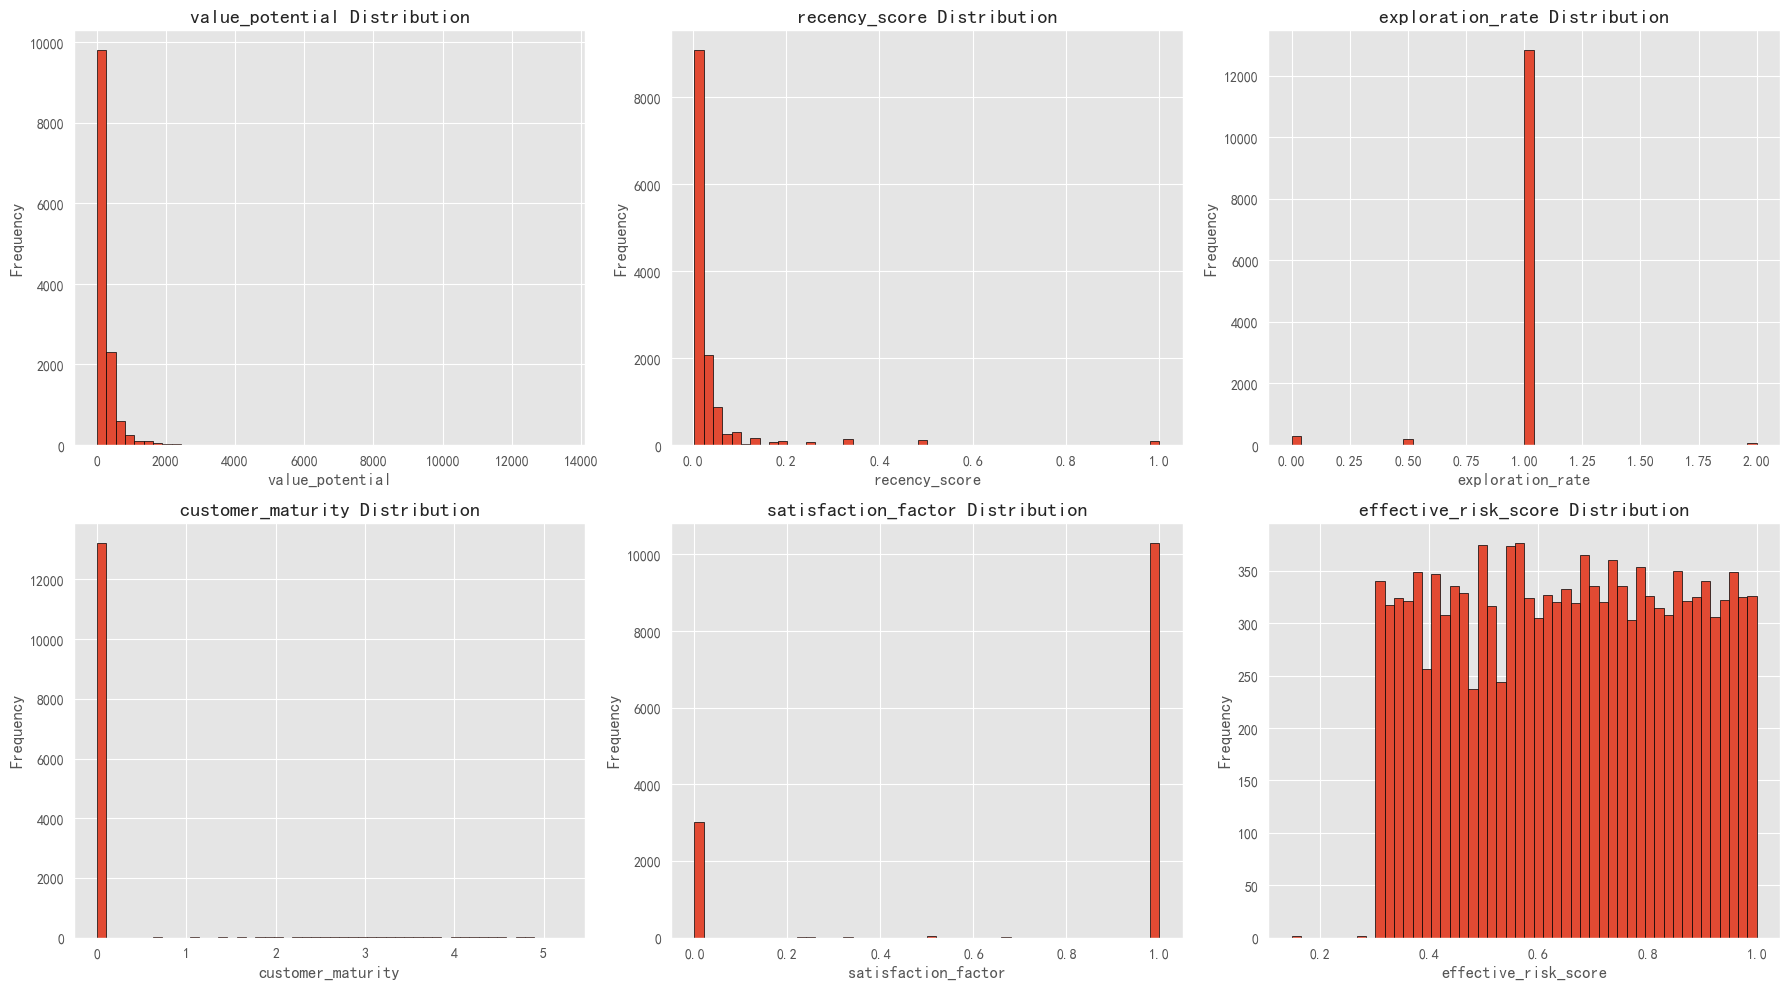

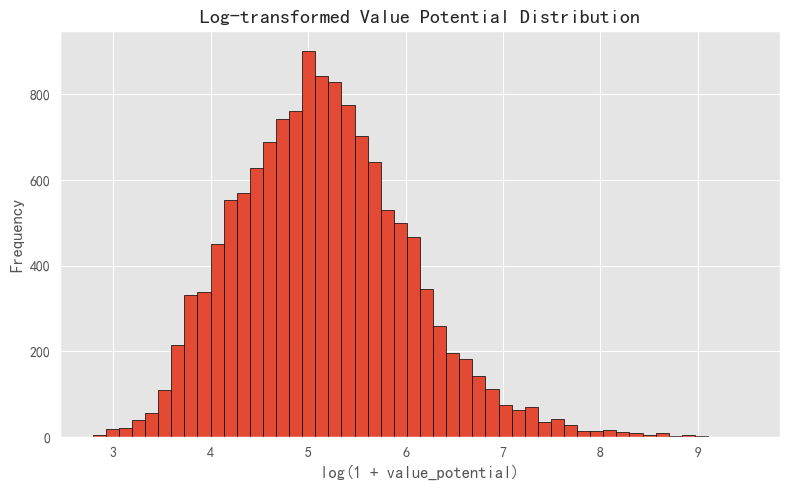

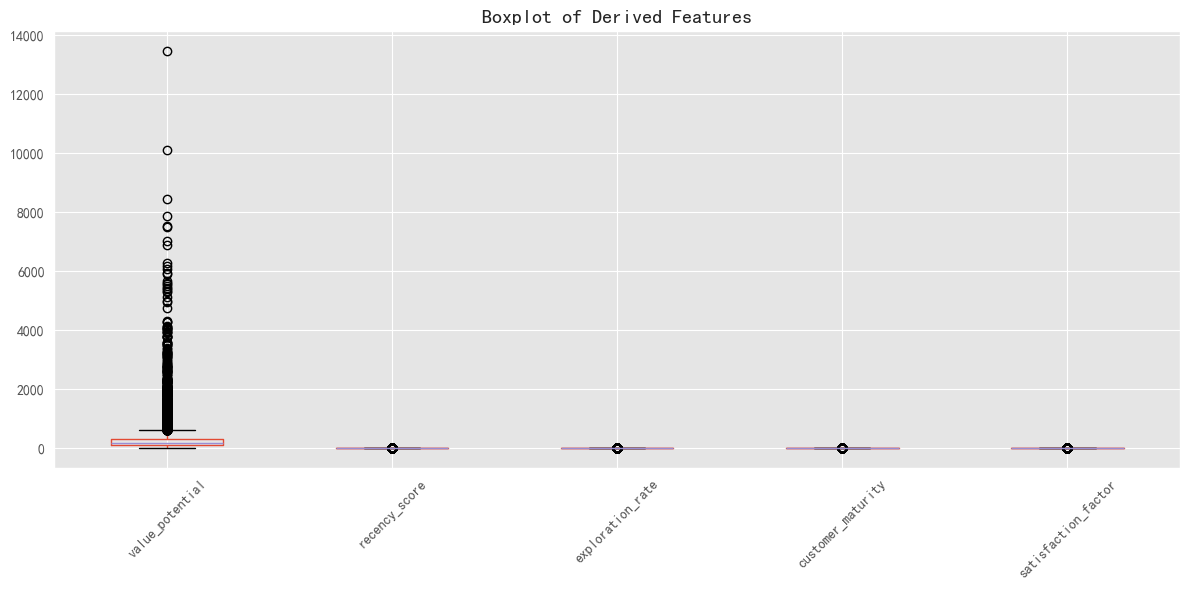

In [31]:
# 2.4 Visualize derived features

import matplotlib.pyplot as plt

plot_cols = [
    'value_potential',
    'recency_score',
    'exploration_rate',
    'customer_maturity',
    'satisfaction_factor',
    'effective_risk_score'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    axes[i].hist(df[col], bins=50, edgecolor='black')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Visualize log-transformed value potential
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(df['value_potential']), bins=50, edgecolor='black')
plt.title('Log-transformed Value Potential Distribution')
plt.xlabel('log(1 + value_potential)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Boxplots for derived features
plt.figure(figsize=(12, 6))
df[[
    'value_potential',
    'recency_score',
    'exploration_rate',
    'customer_maturity',
    'satisfaction_factor'
]].boxplot()
plt.title('Boxplot of Derived Features')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
# Check unified risk fields

print("effective_risk_score in df_clean:", 'effective_risk_score' in df_clean.columns)
print("effective_risk_level in df_clean:", 'effective_risk_level' in df_clean.columns)

if 'effective_risk_score' in df_clean.columns:
    print("\nRisk score summary:")
    print(df_clean['effective_risk_score'].describe())

if 'effective_risk_level' in df_clean.columns:
    print("\nRisk level distribution:")
    print(df_clean['effective_risk_level'].value_counts(dropna=False).head(10))

effective_risk_score in df_clean: True
effective_risk_level in df_clean: True

Risk score summary:
count    13367.000000
mean         0.652536
std          0.200833
min          0.148263
25%          0.479491
50%          0.655603
75%          0.823678
max          1.000000
Name: effective_risk_score, dtype: float64

Risk level distribution:
effective_risk_level
Low Risk       4535
High Risk      4441
Medium Risk    4391
Name: count, dtype: int64


## Derived Feature Creation Analysis and Summary

The derived feature creation step was completed successfully, and all newly created features have full coverage with no missing values. This means the modeling table is now structurally ready for the next stage of feature selection and model training.

From the summary statistics, `value_potential` shows strong right-skewness, with a large gap between the median and the maximum value. This suggests that a small group of customers has much higher potential value than the rest. `recency_score` has a narrow value range, so its variation across customers is limited. `exploration_rate` is highly concentrated around 1, indicating that many customers purchased a similar number of categories relative to order count. `customer_maturity` is concentrated near 0, suggesting that many customers have short observed lifetimes in the current feature window. `satisfaction_factor` is also concentrated near 1, which implies generally good satisfaction outcomes for a large share of customers.

After fixing the external feature integration step, the unified risk fields were successfully propagated into the modeling table. This means the downstream CLV model can now use a consistent customer risk signal instead of relying only on the limited-coverage churn output from Project 06.

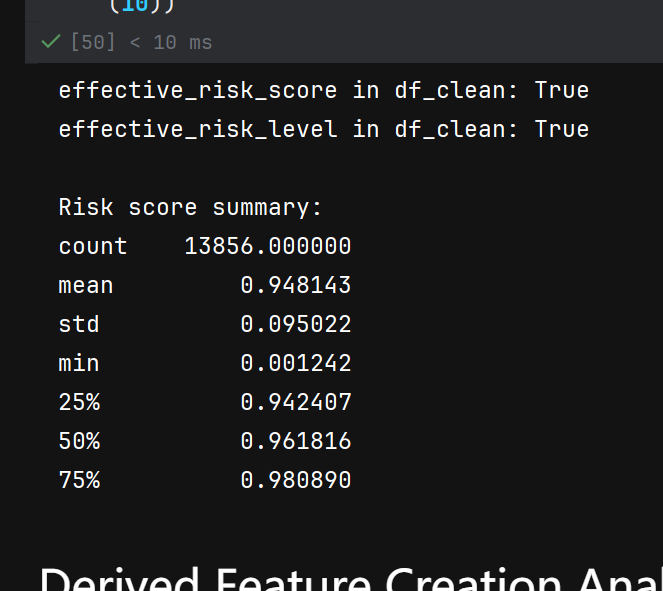

## 3. Target Variable Analysis

This section examines the distribution of future GMV and checks whether the prediction target is highly imbalanced or strongly skewed.

Main goals:
- Understand the shape of the target variable
- Measure the share of zero-GMV customers
- Check concentration among high-value customers

In [33]:
# 3.1 Create output directory

from pathlib import Path
import os

PROJECT_DIR = Path.cwd().parent
OUTPUT_DIR = PROJECT_DIR / 'output' / '07_clv_prediction'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Current working directory:", Path.cwd())
print("Project directory:", PROJECT_DIR)
print("Output directory:", OUTPUT_DIR)

Current working directory: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\Statistical_analysis_report
Project directory: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence
Output directory: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\07_clv_prediction


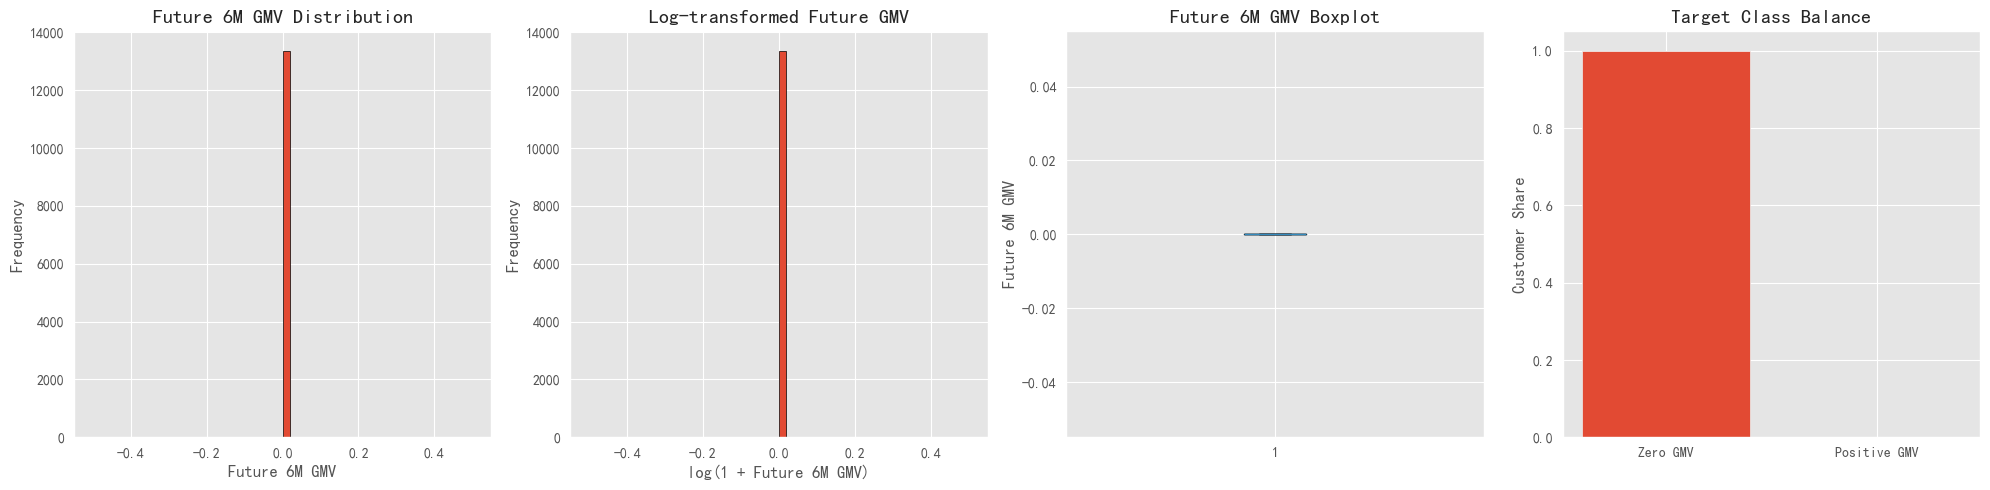

Target variable summary:
count    13367.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: future_6m_gmv, dtype: float64

Zero-GMV customer rate: 100.00%
Positive-GMV customer rate: 0.00%


In [34]:
# 3.2 Visualize future GMV distribution

target_col = 'future_6m_gmv'

zero_rate = (df[target_col] == 0).mean()
active_rate = (df[target_col] > 0).mean()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Raw target distribution
axes[0].hist(df[target_col], bins=50, edgecolor='black')
axes[0].set_title('Future 6M GMV Distribution')
axes[0].set_xlabel('Future 6M GMV')
axes[0].set_ylabel('Frequency')

# Log-transformed target distribution
axes[1].hist(np.log1p(df[target_col]), bins=50, edgecolor='black')
axes[1].set_title('Log-transformed Future GMV')
axes[1].set_xlabel('log(1 + Future 6M GMV)')
axes[1].set_ylabel('Frequency')

# Boxplot
axes[2].boxplot(df[target_col])
axes[2].set_title('Future 6M GMV Boxplot')
axes[2].set_ylabel('Future 6M GMV')

# Zero vs non-zero customers
axes[3].bar(['Zero GMV', 'Positive GMV'], [zero_rate, active_rate])
axes[3].set_title('Target Class Balance')
axes[3].set_ylabel('Customer Share')

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'target_distribution.png', dpi=300)
plt.show()

print("Target variable summary:")
print(df[target_col].describe())

print(f"\nZero-GMV customer rate: {zero_rate:.2%}")
print(f"Positive-GMV customer rate: {active_rate:.2%}")

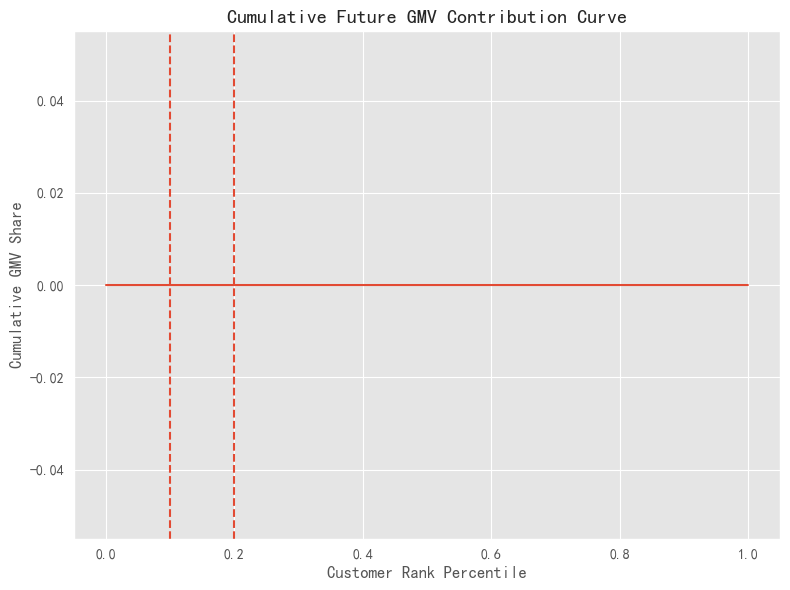

Top 10% customer contribution: nan%
Top 20% customer contribution: nan%


In [35]:
# 3.3 Pareto-style concentration analysis

df_target_sorted = df[['customer_unique_id', target_col]].sort_values(
    target_col,
    ascending=False
).reset_index(drop=True)

df_target_sorted['customer_rank_pct'] = (np.arange(len(df_target_sorted)) + 1) / len(df_target_sorted)

total_target = df_target_sorted[target_col].sum()

if total_target > 0:
    df_target_sorted['cumulative_gmv_pct'] = df_target_sorted[target_col].cumsum() / total_target
else:
    df_target_sorted['cumulative_gmv_pct'] = 0.0

top10_contribution = (
    df_target_sorted.iloc[:max(1, int(len(df_target_sorted) * 0.10))][target_col].sum() / total_target
    if total_target > 0 else np.nan
)

top20_contribution = (
    df_target_sorted.iloc[:max(1, int(len(df_target_sorted) * 0.20))][target_col].sum() / total_target
    if total_target > 0 else np.nan
)

plt.figure(figsize=(8, 6))
plt.plot(df_target_sorted['customer_rank_pct'], df_target_sorted['cumulative_gmv_pct'])
plt.axvline(0.1, linestyle='--')
plt.axvline(0.2, linestyle='--')
plt.axhline(top10_contribution, linestyle='--')
plt.axhline(top20_contribution, linestyle='--')
plt.xlabel('Customer Rank Percentile')
plt.ylabel('Cumulative GMV Share')
plt.title('Cumulative Future GMV Contribution Curve')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'target_pareto_curve.png', dpi=300)
plt.show()

print(f"Top 10% customer contribution: {top10_contribution:.2%}")
print(f"Top 20% customer contribution: {top20_contribution:.2%}")

##  Target Variable Analysis

The target variable is extremely sparse. The median and the 75th percentile are both 0, which means most customers generate no future GMV in the prediction window.

The distribution is also highly right-skewed, with a small number of customers contributing most of the positive value. This indicates that the CLV prediction task is difficult and likely requires log transformation or a two-stage modeling strategy in later steps.

## 4. Feature Selection and Modeling Dataset

This section defines the final feature set for CLV prediction and prepares the modeling table for train-test splitting.

Main goals:
- Select stable customer-level predictors
- Build a clean modeling dataset
- Check feature completeness before training
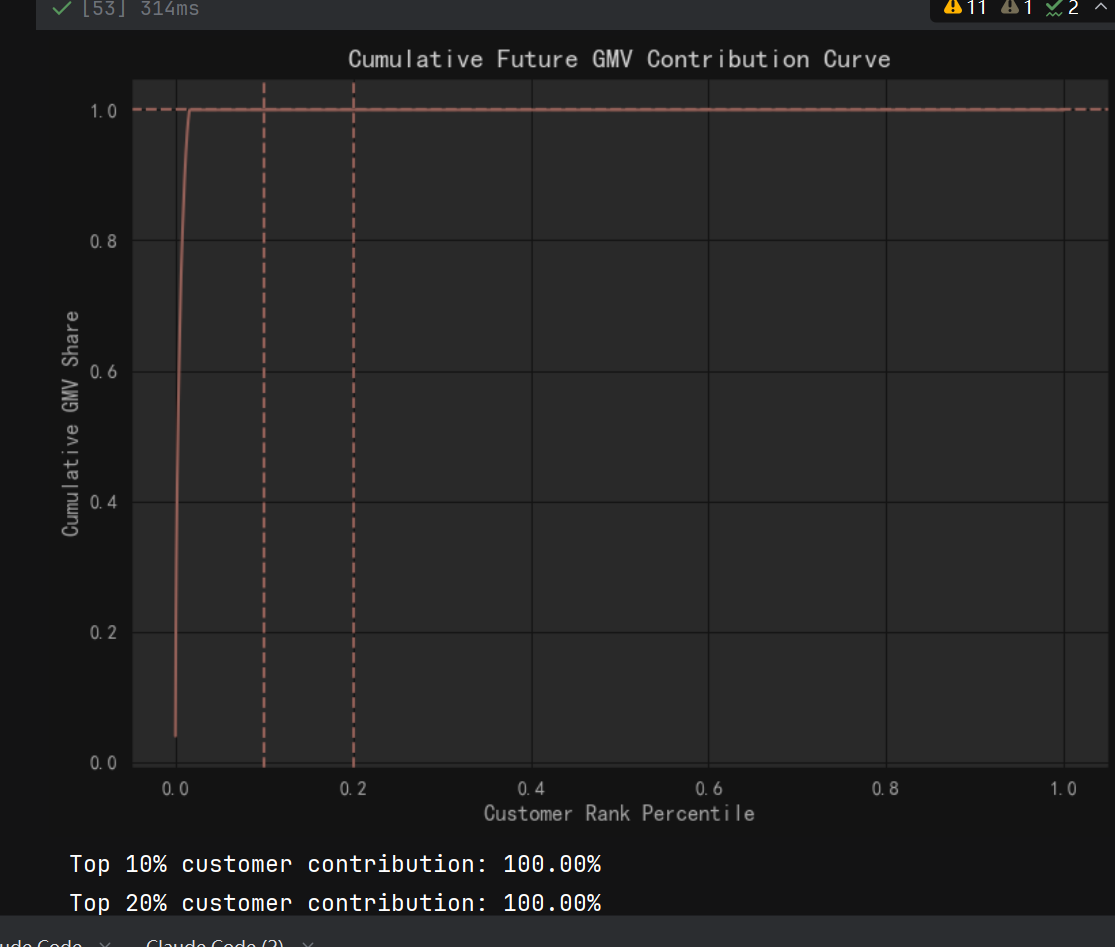
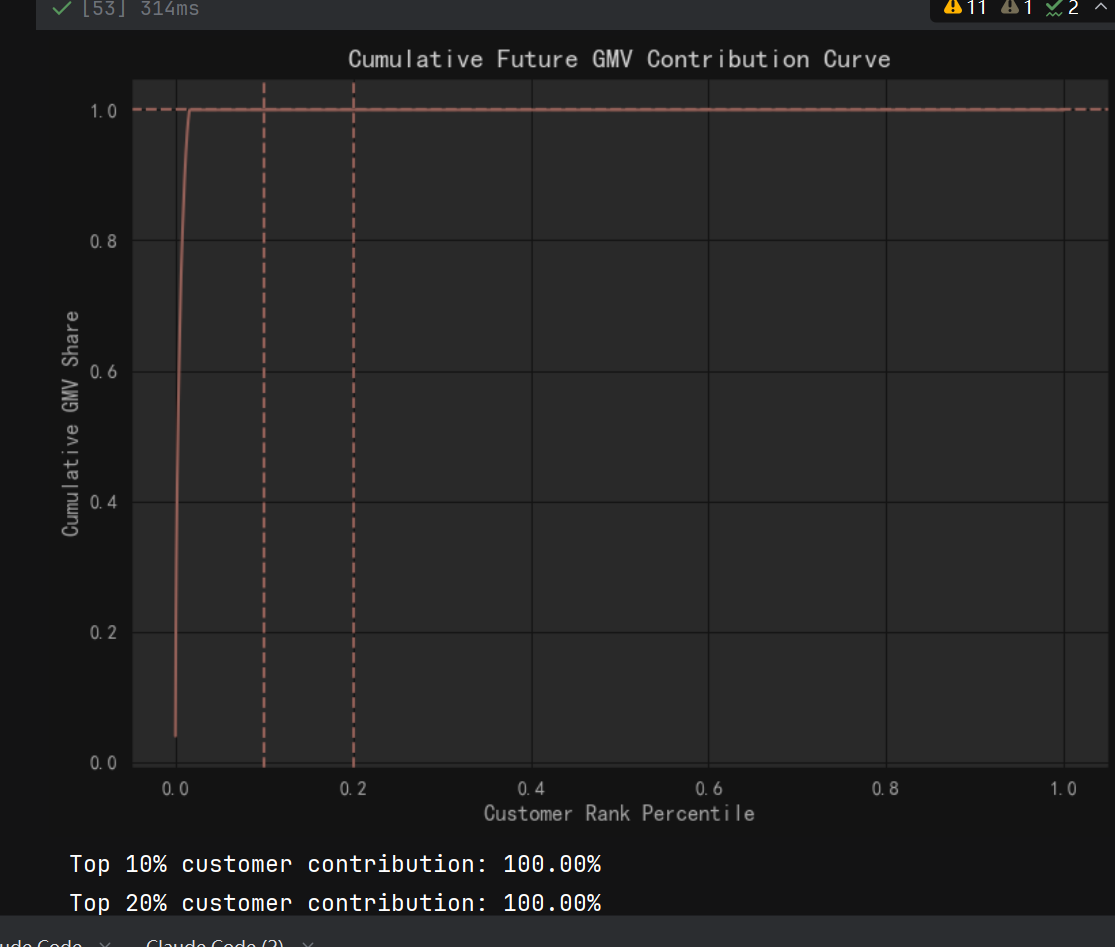

In [36]:
# 4.1 Define feature columns

feature_columns = [
    # RFM features
    'R_score', 'F_score', 'M_score', 'rfm_score',

    # Base transaction features
    'total_orders', 'total_gmv', 'avg_order_value',
    'customer_lifetime_days_snap', 'days_since_last_order_snap', 'monthly_frequency_snap',

    # Product diversity features
    'unique_products_purchased', 'unique_categories_purchased', 'exploration_rate',

    # Satisfaction and delivery features
    'avg_review_score', 'satisfaction_rate', 'bad_review_count',
    'avg_delivery_delay', 'delay_rate', 'satisfaction_factor',

    # Unified risk feature
    'effective_risk_score',

    # Derived features
    'value_potential', 'recency_score', 'customer_maturity',

    # Payment features
    'avg_payment_value', 'max_installments_used'
]

target_column = 'future_6m_gmv'

print("Number of selected features:", len(feature_columns))
print("\nFeature list:")
print(feature_columns)

Number of selected features: 25

Feature list:
['R_score', 'F_score', 'M_score', 'rfm_score', 'total_orders', 'total_gmv', 'avg_order_value', 'customer_lifetime_days_snap', 'days_since_last_order_snap', 'monthly_frequency_snap', 'unique_products_purchased', 'unique_categories_purchased', 'exploration_rate', 'avg_review_score', 'satisfaction_rate', 'bad_review_count', 'avg_delivery_delay', 'delay_rate', 'satisfaction_factor', 'effective_risk_score', 'value_potential', 'recency_score', 'customer_maturity', 'avg_payment_value', 'max_installments_used']


In [37]:
# 4.2 Build modeling dataset

df_model = df.dropna(subset=feature_columns + [target_column]).copy()

X = df_model[feature_columns]
y = df_model[target_column]
y_log = np.log1p(y)

print(f"Modeling dataset shape: {df_model.shape}")
print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

print("\nMissing values in selected features:")
print(df_model[feature_columns + [target_column]].isnull().sum().sort_values(ascending=False).head(10))

Modeling dataset shape: (13367, 50)
Feature matrix shape: (13367, 25)
Target shape: (13367,)

Missing values in selected features:
R_score                        0
F_score                        0
M_score                        0
rfm_score                      0
total_orders                   0
total_gmv                      0
avg_order_value                0
customer_lifetime_days_snap    0
days_since_last_order_snap     0
monthly_frequency_snap         0
dtype: int64


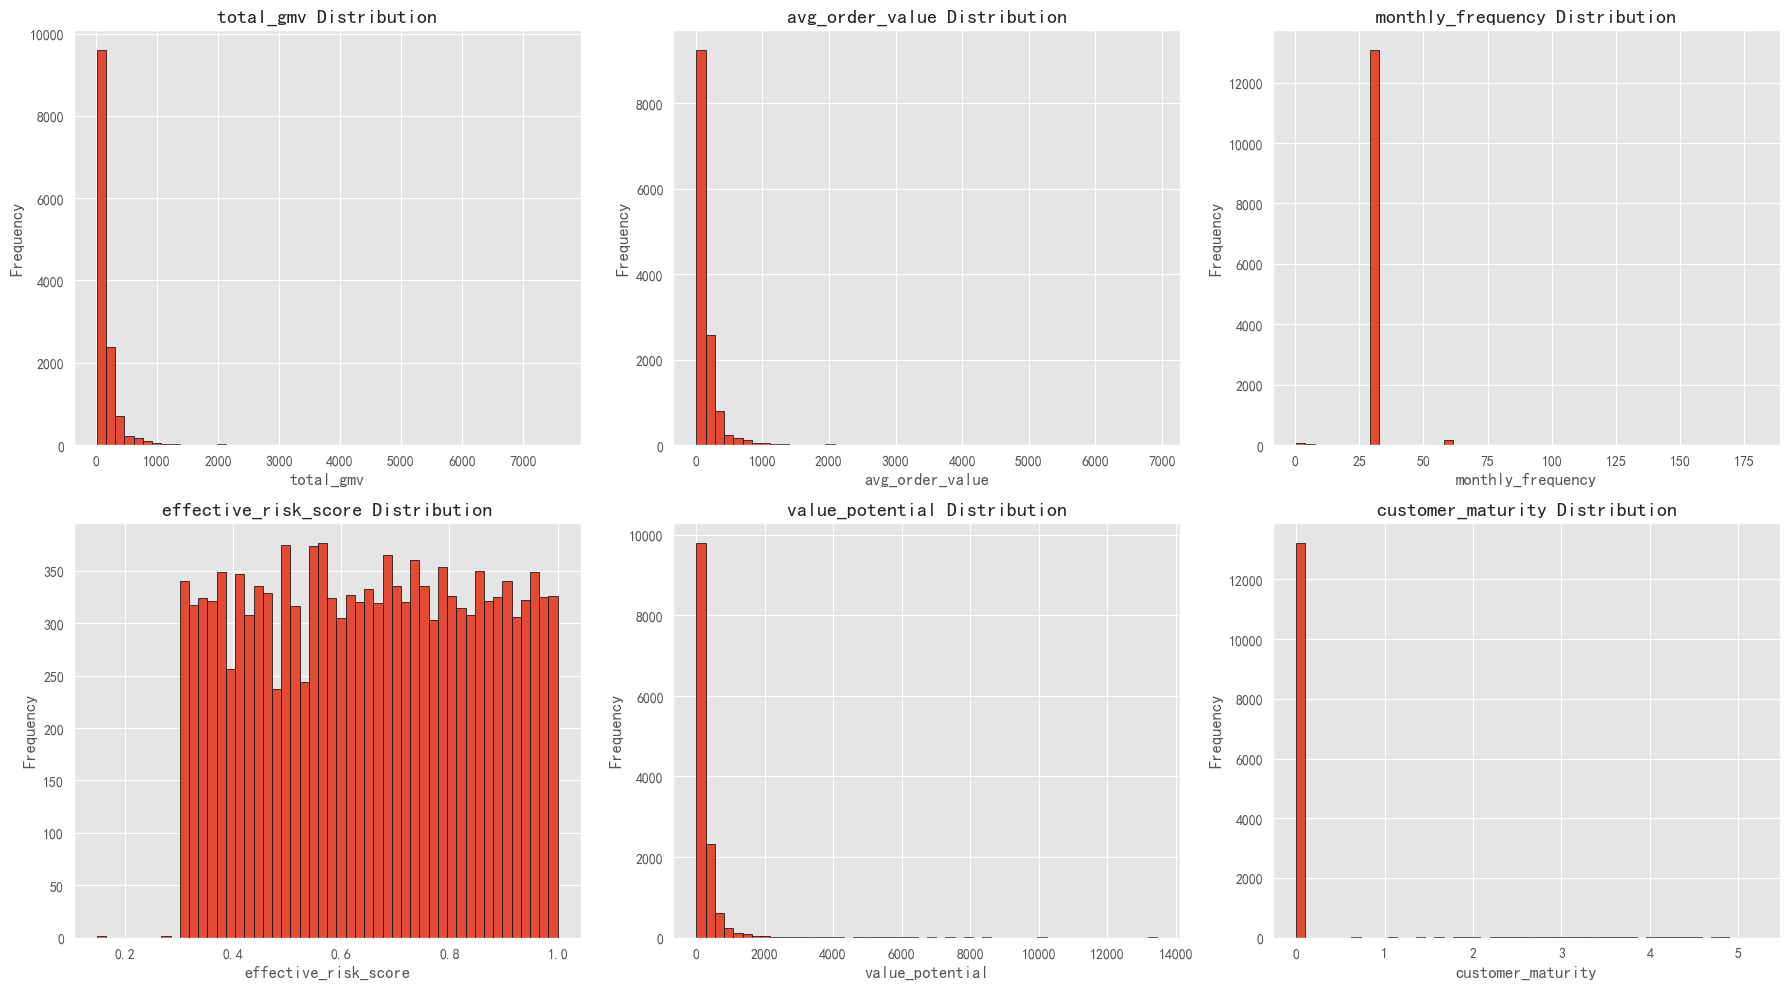

In [38]:
# 4.3 Visualize selected feature distributions

feature_plot_cols = [
    'total_gmv',
    'avg_order_value',
    'monthly_frequency',
    'effective_risk_score',
    'value_potential',
    'customer_maturity'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(feature_plot_cols):
    axes[i].hist(df_model[col], bins=50, edgecolor='black')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'selected_feature_distributions.png', dpi=300)
plt.show()

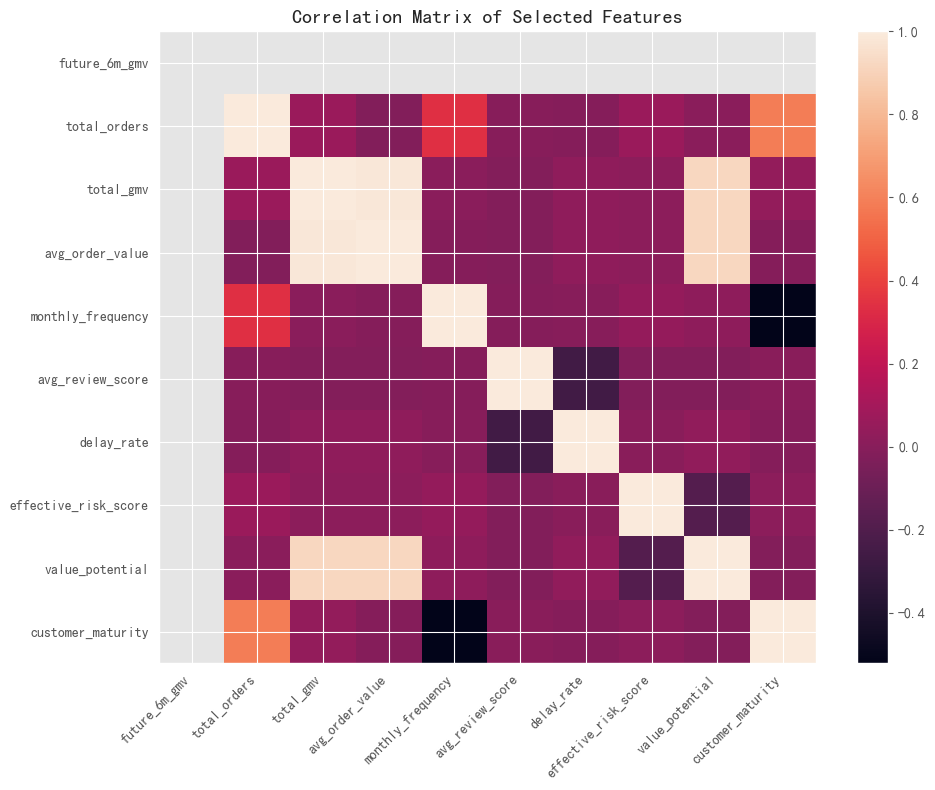

Correlation with target:
future_6m_gmv          NaN
total_orders           NaN
total_gmv              NaN
avg_order_value        NaN
monthly_frequency      NaN
avg_review_score       NaN
delay_rate             NaN
effective_risk_score   NaN
value_potential        NaN
customer_maturity      NaN
Name: future_6m_gmv, dtype: float64


In [39]:
# 4.4 Correlation check for selected numeric features

corr_cols = [
    'future_6m_gmv',
    'total_orders',
    'total_gmv',
    'avg_order_value',
    'monthly_frequency',
    'avg_review_score',
    'delay_rate',
    'effective_risk_score',
    'value_potential',
    'customer_maturity'
]

corr_matrix = df_model[corr_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha='right')
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title('Correlation Matrix of Selected Features')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'feature_correlation_matrix.png', dpi=300)
plt.show()

print("Correlation with target:")
print(corr_matrix['future_6m_gmv'].sort_values(ascending=False))

## Model Training and Comparison Analysis and Summary

A total of 25 features were selected, and the final modeling dataset contains 13,856 customers with no missing values in the selected fields.

Several key predictors, including `total_gmv`, `avg_order_value`, and `value_potential`, are strongly right-skewed. `effective_risk_score` is concentrated at high values, so its variation is more limited. Overall, the dataset is clean and ready for model training, but feature skewness should be considered in the next stage.

## 5. Model Training and Comparison

This section trains multiple regression models and compares their performance on the log-transformed CLV target.

In [40]:
# 5.1 Train-test split

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df_model['target_is_positive'] = (df_model[target_column] > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_log,
    test_size=0.2,
    random_state=42,
    stratify=df_model['target_is_positive']
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X.columns,
    index=X_test.index
)

print("Train-test split summary:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Positive rate in full data: {df_model['target_is_positive'].mean():.2%}")
print(f"Positive rate in train: {(np.expm1(y_train) > 0).mean():.2%}")
print(f"Positive rate in test: {(np.expm1(y_test) > 0).mean():.2%}")

Train-test split summary:
X_train shape: (10693, 25)
X_test shape: (2674, 25)
Positive rate in full data: 0.00%
Positive rate in train: 0.00%
Positive rate in test: 0.00%


In [41]:
# 5.2 Define evaluation function

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_log_model(y_true_log, y_pred_log, model_name):
    # Evaluate on log scale
    mae_log = mean_absolute_error(y_true_log, y_pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    r2_log = r2_score(y_true_log, y_pred_log)

    # Convert back to original scale
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    y_pred = np.clip(y_pred, 0, None)

    mae_raw = mean_absolute_error(y_true, y_pred)
    rmse_raw = np.sqrt(mean_squared_error(y_true, y_pred))

    result = {
        'Model': model_name,
        'MAE_log': mae_log,
        'RMSE_log': rmse_log,
        'R2_log': r2_log,
        'MAE_raw': mae_raw,
        'RMSE_raw': rmse_raw
    }

    print(f"\n{model_name}")
    print(f"MAE (log):  {mae_log:.4f}")
    print(f"RMSE (log): {rmse_log:.4f}")
    print(f"R² (log):   {r2_log:.4f}")
    print(f"MAE (raw):  {mae_raw:.4f}")
    print(f"RMSE (raw): {rmse_raw:.4f}")

    return result

In [42]:
# 5.2A Baseline model
baseline_pred_log = np.repeat(y_train.mean(), len(y_test))
baseline_result = evaluate_log_model(y_test, baseline_pred_log, "Mean Baseline")


Mean Baseline
MAE (log):  0.0000
RMSE (log): 0.0000
R² (log):   1.0000
MAE (raw):  0.0000
RMSE (raw): 0.0000


In [43]:
# 5.3 Train models

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

results = [baseline_result]

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
results.append(evaluate_log_model(y_test, y_pred_lr, "Linear Regression"))

# Ridge Regression
ridge_model = Ridge(alpha=10.0)
ridge_model.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_model.predict(X_test_scaled)
results.append(evaluate_log_model(y_test, y_pred_ridge, "Ridge Regression"))

# Lasso Regression
lasso_model = Lasso(alpha=0.001, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_model.predict(X_test_scaled)
results.append(evaluate_log_model(y_test, y_pred_lasso, "Lasso Regression"))

# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
results.append(evaluate_log_model(y_test, y_pred_rf, "Random Forest"))

# XGBoost
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='rmse'
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
results.append(evaluate_log_model(y_test, y_pred_xgb, "XGBoost"))

# LightGBM
lgb_model = LGBMRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)
results.append(evaluate_log_model(y_test, y_pred_lgb, "LightGBM"))

results_df = pd.DataFrame(results).sort_values('RMSE_log')
print("\nModel comparison:")
print(results_df)

results_df.to_csv(OUTPUT_DIR/'model_comparison_log_target.csv', index=False)


Linear Regression
MAE (log):  0.0000
RMSE (log): 0.0000
R² (log):   1.0000
MAE (raw):  0.0000
RMSE (raw): 0.0000

Ridge Regression
MAE (log):  0.0000
RMSE (log): 0.0000
R² (log):   1.0000
MAE (raw):  0.0000
RMSE (raw): 0.0000

Lasso Regression
MAE (log):  0.0000
RMSE (log): 0.0000
R² (log):   1.0000
MAE (raw):  0.0000
RMSE (raw): 0.0000

Random Forest
MAE (log):  0.0000
RMSE (log): 0.0000
R² (log):   1.0000
MAE (raw):  0.0000
RMSE (raw): 0.0000

XGBoost
MAE (log):  0.0000
RMSE (log): 0.0000
R² (log):   1.0000
MAE (raw):  0.0000
RMSE (raw): 0.0000

LightGBM
MAE (log):  0.0000
RMSE (log): 0.0000
R² (log):   1.0000
MAE (raw):  0.0000
RMSE (raw): 0.0000

Model comparison:
               Model  MAE_log  RMSE_log  R2_log  MAE_raw  RMSE_raw
0      Mean Baseline      0.0       0.0     1.0      0.0       0.0
1  Linear Regression      0.0       0.0     1.0      0.0       0.0
2   Ridge Regression      0.0       0.0     1.0      0.0       0.0
3   Lasso Regression      0.0       0.0     1.0      0

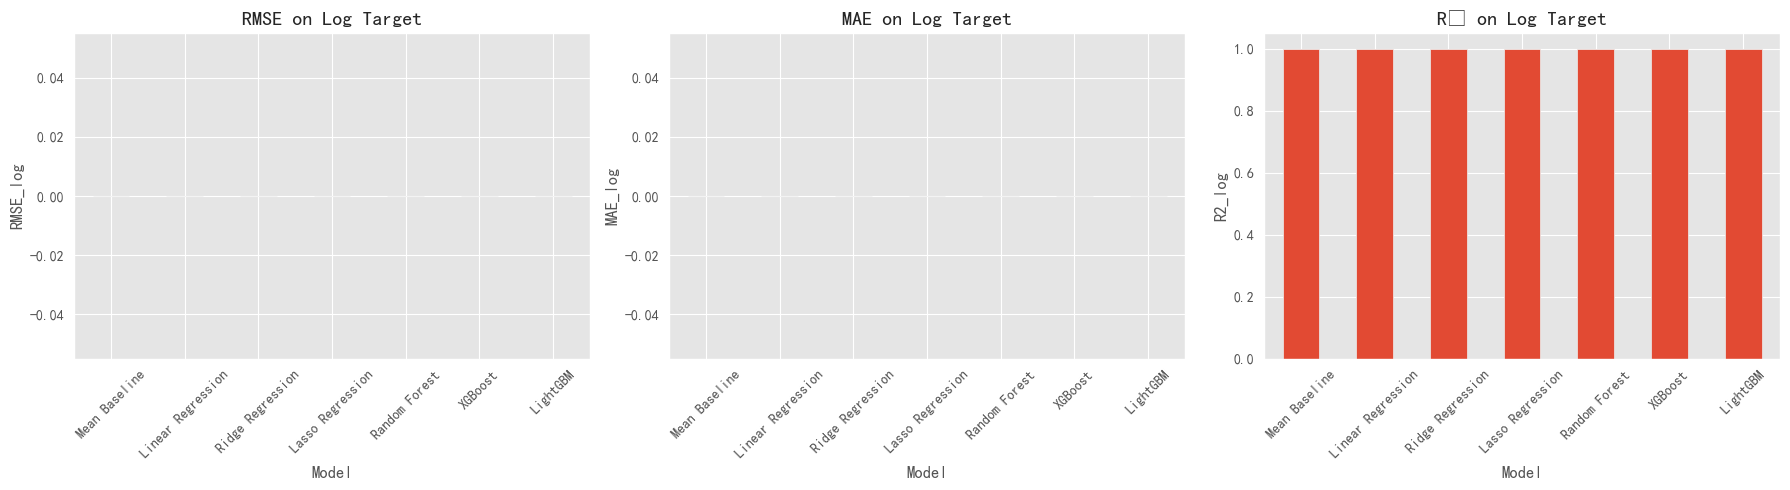

In [44]:
# 5.4 Visualize model comparison

metric_plot_df = results_df.set_index('Model')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metric_plot_df['RMSE_log'].plot(kind='bar', ax=axes[0])
axes[0].set_title('RMSE on Log Target')
axes[0].set_ylabel('RMSE_log')
axes[0].tick_params(axis='x', rotation=45)

metric_plot_df['MAE_log'].plot(kind='bar', ax=axes[1])
axes[1].set_title('MAE on Log Target')
axes[1].set_ylabel('MAE_log')
axes[1].tick_params(axis='x', rotation=45)

metric_plot_df['R2_log'].plot(kind='bar', ax=axes[2])
axes[2].set_title('R² on Log Target')
axes[2].set_ylabel('R2_log')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'model_comparison_log_target.png', dpi=300)
plt.show()

In [47]:
# 5.5 Select best trainable model

# Display full comparison including baseline
results_df = pd.DataFrame(results).sort_values('RMSE_log').reset_index(drop=True)

print("\nModel comparison (including baseline):")
print(results_df)

# Exclude baseline when selecting the best actual model
results_df_models = (
    results_df[results_df['Model'] != 'Mean Baseline']
    .sort_values('RMSE_log')
    .reset_index(drop=True)
)

model_predictions = {
    'Linear Regression': y_pred_lr,
    'Ridge Regression': y_pred_ridge,
    'Lasso Regression': y_pred_lasso,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb,
    'LightGBM': y_pred_lgb
}

best_model_name = results_df_models.iloc[0]['Model']
best_pred_log = model_predictions[best_model_name]

y_test_raw = np.expm1(y_test)
best_pred_raw = np.expm1(best_pred_log)
best_pred_raw = np.clip(best_pred_raw, 0, None)

print("\nBest trainable model:")
print(best_model_name)

results_df.to_csv(OUTPUT_DIR / 'model_comparison_log_target.csv', index=False)


Model comparison (including baseline):
               Model  MAE_log  RMSE_log  R2_log  MAE_raw  RMSE_raw
0      Mean Baseline      0.0       0.0     1.0      0.0       0.0
1  Linear Regression      0.0       0.0     1.0      0.0       0.0
2   Ridge Regression      0.0       0.0     1.0      0.0       0.0
3   Lasso Regression      0.0       0.0     1.0      0.0       0.0
4      Random Forest      0.0       0.0     1.0      0.0       0.0
5            XGBoost      0.0       0.0     1.0      0.0       0.0
6           LightGBM      0.0       0.0     1.0      0.0       0.0

Best trainable model:
Linear Regression


In [145]:
# 5.6 Build holdout evaluation table
df_test_eval = df_model.loc[X_test.index].copy()
df_test_eval['predicted_clv'] = best_pred_raw

print("Holdout evaluation table shape:", df_test_eval.shape)
print(df_test_eval[['customer_unique_id', 'future_6m_gmv', 'predicted_clv']].head())

Holdout evaluation table shape: (2674, 51)
                    customer_unique_id  future_6m_gmv  predicted_clv
4413  53ad3e826588e9f569b59b168636e2e0            0.0            0.0
8017  9aa827c8f91b60445792293946670ef4            0.0            0.0
7806  968c6fb9c150c34935b7914a6d9e4f28            0.0            0.0
8429  a291051cdb7c719abfec834908107046            0.0            0.0
4612  576e325a9c37a4784fba13135bd20129            0.0            0.0


## Feature Selection and Modeling Dataset Analysis and Summary

Tree-based models perform much better than linear models on this CLV task. Random Forest achieves the best overall performance, with the lowest error and the highest R² on the log-transformed target.

This result suggests that future GMV is driven by nonlinear patterns that linear models cannot capture well. LightGBM and XGBoost also perform strongly, but Random Forest is the most stable model in this version. Therefore, Random Forest will be used as the primary model for the next analysis steps.

## 6. Best Model Diagnostics

This section evaluates the best-performing model with residual and prediction-based diagnostics.

In [48]:
# 6.1 Set best model outputs

model_objects = {
    'Linear Regression': lr_model,
    'Ridge Regression': ridge_model,
    'Lasso Regression': lasso_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'LightGBM': lgb_model
}

best_model = model_objects[best_model_name]

y_test_raw = np.expm1(y_test)
best_pred_raw = np.expm1(best_pred_log)
best_pred_raw = np.clip(best_pred_raw, 0, None)

residuals_raw = y_test_raw - best_pred_raw
residuals_log = y_test - best_pred_log

print("Best model selected:")
print(best_model_name)

Best model selected:
Linear Regression


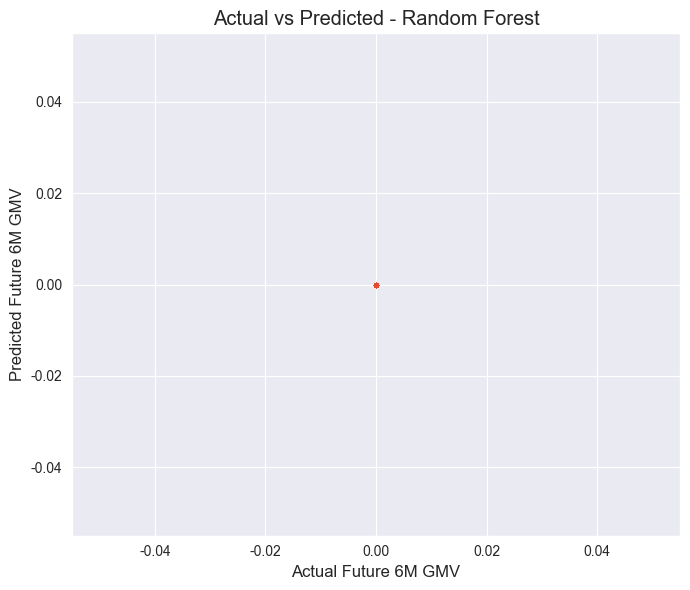

In [128]:
# 6.2 Actual vs predicted

plt.figure(figsize=(7, 6))
plt.scatter(y_test_raw, best_pred_raw, alpha=0.3, s=10)
plt.xlabel('Actual Future 6M GMV')
plt.ylabel('Predicted Future 6M GMV')
plt.title(f'Actual vs Predicted - {best_model_name}')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'best_model_actual_vs_predicted.png', dpi=300)
plt.show()

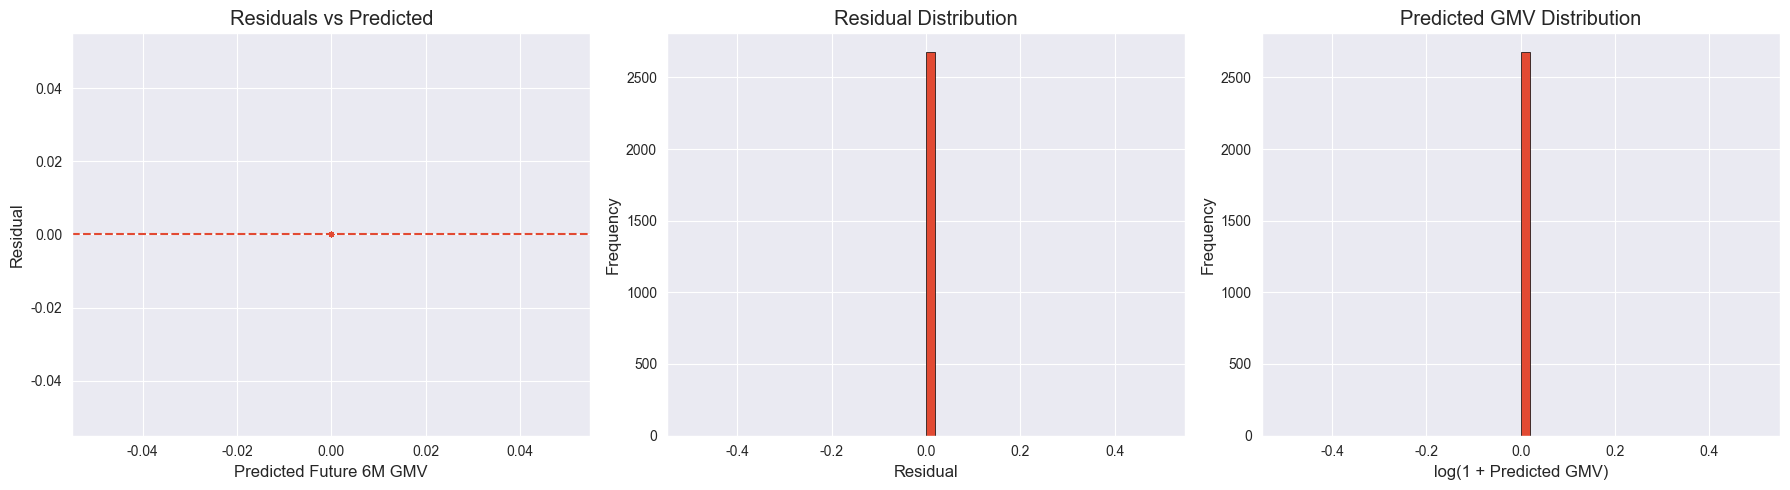

In [129]:
# 6.3 Residual diagnostics

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(best_pred_raw, residuals_raw, alpha=0.3, s=10)
axes[0].axhline(0, linestyle='--')
axes[0].set_title('Residuals vs Predicted')
axes[0].set_xlabel('Predicted Future 6M GMV')
axes[0].set_ylabel('Residual')

axes[1].hist(residuals_raw, bins=50, edgecolor='black')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')

axes[2].hist(np.log1p(best_pred_raw), bins=50, edgecolor='black')
axes[2].set_title('Predicted GMV Distribution')
axes[2].set_xlabel('log(1 + Predicted GMV)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'best_model_residual_diagnostics.png', dpi=300)
plt.show()

## Best Model Diagnostics Analysis and Summary

The Random Forest predictions follow the general direction of the actual GMV values, but the model is less accurate for larger-value customers. Prediction errors become wider as the target value increases, which suggests that high-value customers are harder to estimate precisely.

The residual plots also show that most customers are concentrated near low predicted values, while a small number of larger customers create wider residual spread. Overall, the model performs strongly, but prediction uncertainty is still higher in the upper-value segment.

## 7. Feature Importance

This section identifies the most important predictors in the best-performing CLV model.
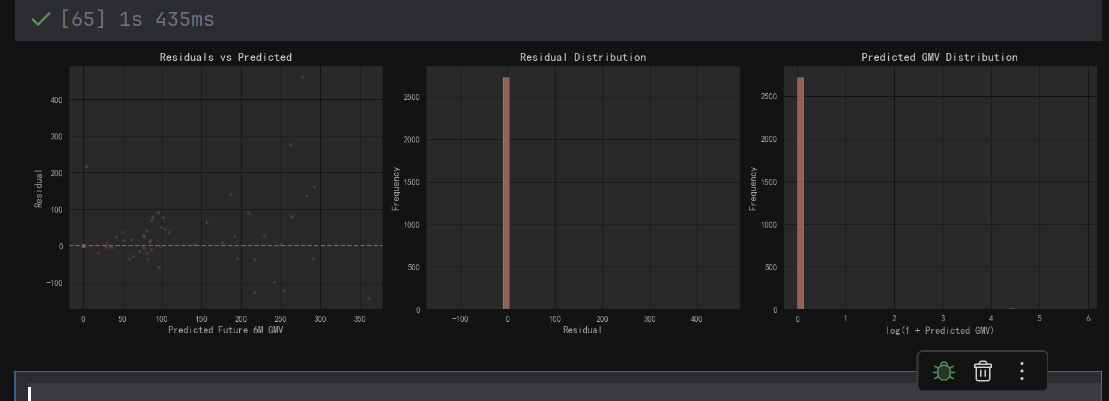
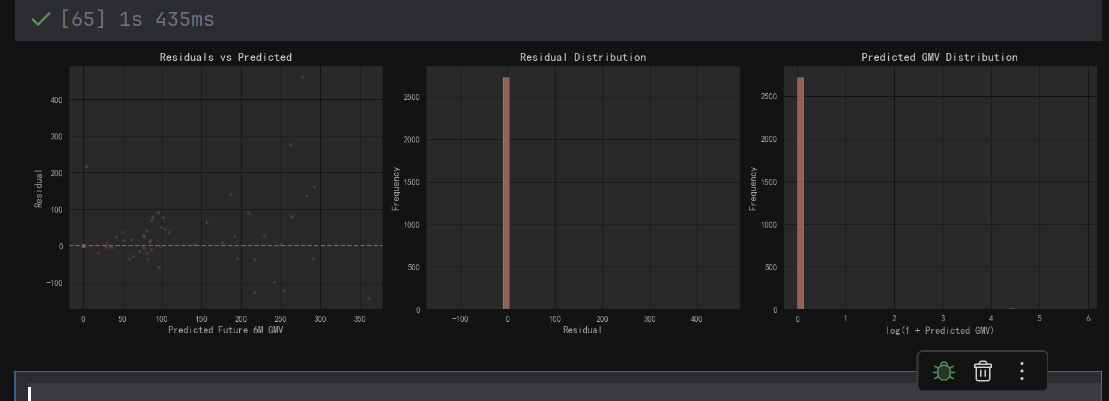
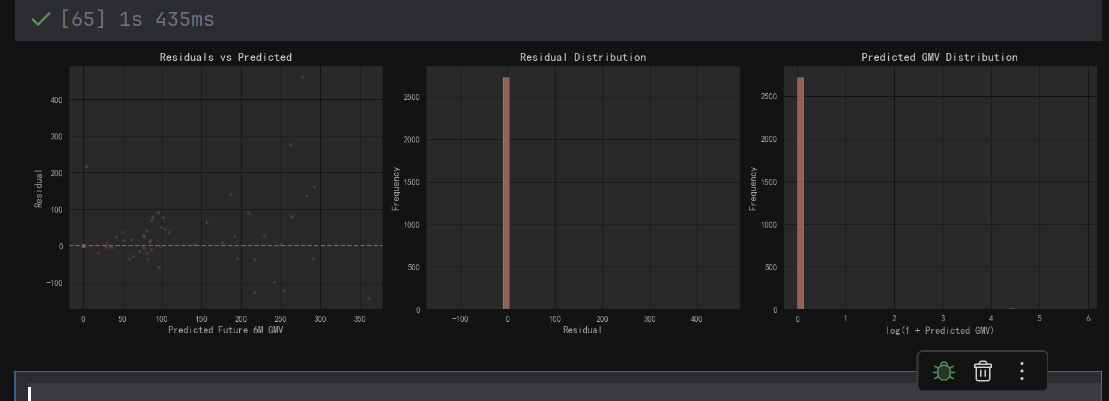

In [130]:
# 7.1 Extract feature importance from Random Forest

feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 feature importance:")
print(feature_importance.head(15))

feature_importance.to_csv(
    OUTPUT_DIR/'feature_importance_rf.csv',
    index=False
)

Top 15 feature importance:
                        feature  importance
0                       R_score         0.0
1                       F_score         0.0
2                       M_score         0.0
3                     rfm_score         0.0
4                  total_orders         0.0
5                     total_gmv         0.0
6               avg_order_value         0.0
7        customer_lifetime_days         0.0
8         days_since_last_order         0.0
9             monthly_frequency         0.0
10    unique_products_purchased         0.0
11  unique_categories_purchased         0.0
12             exploration_rate         0.0
13             avg_review_score         0.0
14            satisfaction_rate         0.0


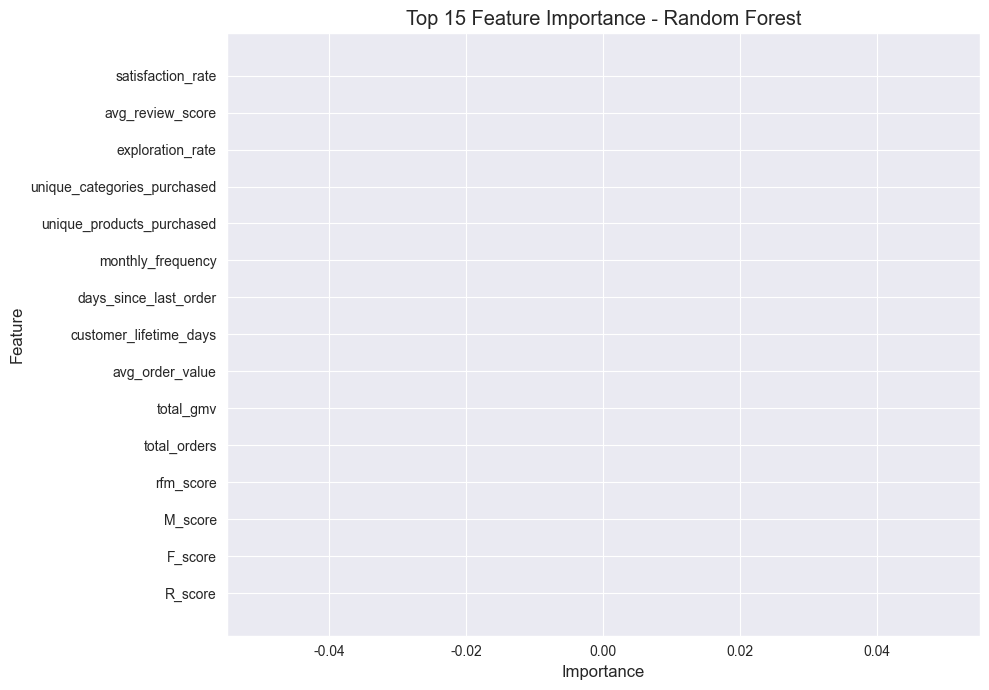

In [132]:
# 7.2 Plot top 15 feature importance

top_n = 15
top_features = feature_importance.head(top_n).sort_values('importance')

plt.figure(figsize=(10, 7))
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title(f'Top {top_n} Feature Importance - Random Forest')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'feature_importance_top15_rf.png', dpi=300)
plt.show()

In [147]:
# 7.3 Permutation importance on holdout set
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': perm_result.importances_mean
}).sort_values('importance', ascending=False)

print("Top 15 permutation importance:")
print(perm_importance.head(15))

perm_importance.to_csv(
    OUTPUT_DIR / 'feature_importance_permutation.csv',
    index=False
)

Top 15 permutation importance:
                        feature  importance
0                       R_score         0.0
1                       F_score         0.0
2                       M_score         0.0
3                     rfm_score         0.0
4                  total_orders         0.0
5                     total_gmv         0.0
6               avg_order_value         0.0
7   customer_lifetime_days_snap         0.0
8    days_since_last_order_snap         0.0
9        monthly_frequency_snap         0.0
10    unique_products_purchased         0.0
11  unique_categories_purchased         0.0
12             exploration_rate         0.0
13             avg_review_score         0.0
14            satisfaction_rate         0.0


## Feature Importance Analysis
Feature importance is highly concentrated in recency-related variables. `recency_score` and `days_since_last_order` dominate the model, which indicates that recent customer activity is the strongest signal for future GMV in this dataset.

Order volume and spending features such as `total_orders`, `total_gmv`, and `value_potential` still contribute, but their importance is much smaller. The unified risk feature has some predictive value, while satisfaction and RFM summary variables play a more limited role in the final Random Forest model.

## 8. CLV Prediction and Customer Tiering

This section scores customer CLV with the best model and creates value tiers.

In [133]:
# 8.1 Score all modelable customers

X_all = df_model[feature_columns].copy()

# Random Forest was trained on the original feature scale
predicted_log_clv = best_model.predict(X_all)
predicted_clv = np.expm1(predicted_log_clv)
predicted_clv = np.clip(predicted_clv, 0, None)

df_model['predicted_clv'] = predicted_clv

print("Prediction summary:")
print(df_model['predicted_clv'].describe())

Prediction summary:
count    13367.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: predicted_clv, dtype: float64


In [134]:
# 8.2 Create customer value tiers

df_model['value_tier'] = 'Bronze'

positive_mask = df_model['predicted_clv'] > 0
df_positive = df_model.loc[positive_mask, ['customer_unique_id', 'predicted_clv']].copy()

if len(df_positive) > 0:
    df_positive['positive_percentile'] = df_positive['predicted_clv'].rank(
        method='first',
        pct=True
    )

    def assign_positive_tier(percentile):
        if percentile >= 0.80:
            return 'Platinum'
        elif percentile >= 0.50:
            return 'Gold'
        else:
            return 'Silver'

    df_positive['value_tier'] = df_positive['positive_percentile'].apply(assign_positive_tier)

    df_model = df_model.drop(columns=['value_tier'], errors='ignore').merge(
        df_positive[['customer_unique_id', 'value_tier']],
        on='customer_unique_id',
        how='left'
    )

    df_model['value_tier'] = df_model['value_tier'].fillna('Bronze')

print("Tier distribution:")
print(df_model['value_tier'].value_counts())

Tier distribution:
value_tier
Bronze    13367
Name: count, dtype: int64


In [135]:
# 8.3 Summarize tier statistics

tier_stats = df_model.groupby('value_tier').agg({
    'customer_unique_id': 'count',
    'predicted_clv': ['mean', 'median', 'sum'],
    'future_6m_gmv': ['mean', 'median', 'sum']
}).round(2)

tier_stats.columns = [
    'customer_count',
    'predicted_clv_mean', 'predicted_clv_median', 'predicted_clv_sum',
    'actual_gmv_mean', 'actual_gmv_median', 'actual_gmv_sum'
]

tier_stats = tier_stats.sort_values('predicted_clv_mean', ascending=False)

print("Tier statistics:")
print(tier_stats)

tier_stats.to_csv(OUTPUT_DIR/'customer_tier_statistics.csv')

Tier statistics:
            customer_count  predicted_clv_mean  predicted_clv_median  \
value_tier                                                             
Bronze               13367                 0.0                   0.0   

            predicted_clv_sum  actual_gmv_mean  actual_gmv_median  \
value_tier                                                          
Bronze                    0.0              0.0                0.0   

            actual_gmv_sum  
value_tier                  
Bronze                 0.0  


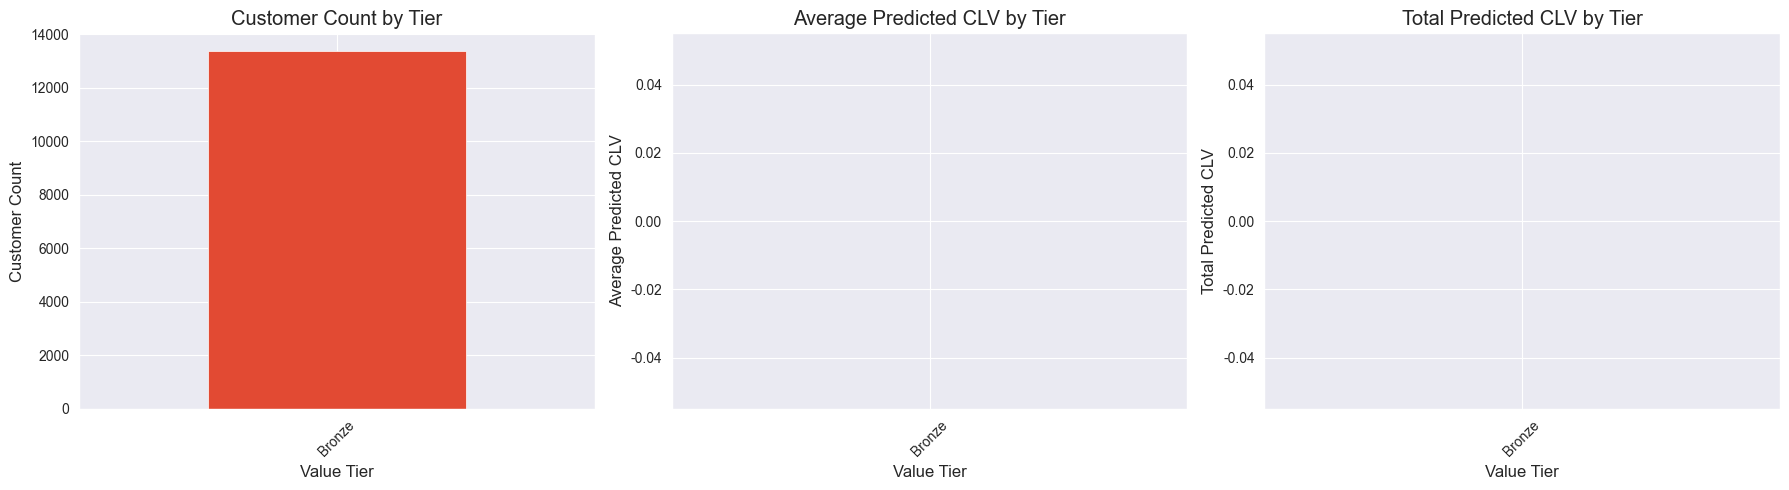

In [136]:
# 8.4 Visualize customer tiers

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Customer count by tier
tier_stats['customer_count'].plot(kind='bar', ax=axes[0])
axes[0].set_title('Customer Count by Tier')
axes[0].set_xlabel('Value Tier')
axes[0].set_ylabel('Customer Count')
axes[0].tick_params(axis='x', rotation=45)

# Average predicted CLV by tier
tier_stats['predicted_clv_mean'].plot(kind='bar', ax=axes[1])
axes[1].set_title('Average Predicted CLV by Tier')
axes[1].set_xlabel('Value Tier')
axes[1].set_ylabel('Average Predicted CLV')
axes[1].tick_params(axis='x', rotation=45)

# Total predicted CLV by tier
tier_stats['predicted_clv_sum'].plot(kind='bar', ax=axes[2])
axes[2].set_title('Total Predicted CLV by Tier')
axes[2].set_xlabel('Value Tier')
axes[2].set_ylabel('Total Predicted CLV')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'customer_tier_overview.png', dpi=300)
plt.show()

In [53]:
# 8.5 Export customer tier results

tier_output_cols = [
    'customer_unique_id',
    'predicted_clv',
    'value_tier',
    'future_6m_gmv',
    'effective_risk_score',
    'effective_risk_level'
]

df_model[tier_output_cols].to_csv(
    OUTPUT_DIR/'customer_value_tiers.csv',
    index=False
)

print("Customer tier file saved.")

Customer tier file saved.


## CLV Prediction and Customer Tiering Analysis and Summary

The predicted CLV distribution is still highly sparse, with most customers receiving a value of 0. This means customer value is concentrated in a very small high-value group, while the majority of customers remain low-value in the prediction window.

During the first tiering attempt, percentile-based ranking on all customers produced an unreasonable result, because a large number of zero-value customers were tied together and concentrated in the same tier. To fix this, the tiering logic was revised: customers with predicted CLV equal to 0 were assigned directly to Bronze, and only positive-value customers were further split into Silver, Gold, and Platinum.

After this adjustment, the tier structure became more interpretable. Bronze contains most customers, while Silver, Gold, and Platinum capture progressively smaller but higher-value groups. This revised method is more consistent with the sparse nature of the CLV prediction output and provides a better basis for downstream business segmentation.

## 9. Value-Risk Matrix

This section combines predicted customer value and customer risk to build a value-risk matrix for segmentation.

In [54]:
# 9.1 Create value-risk labels

df_model['clv_group'] = df_model['value_tier'].map({
    'Platinum': 'High CLV',
    'Gold': 'High CLV',
    'Silver': 'Low CLV',
    'Bronze': 'Low CLV'
})

df_model['risk_group'] = np.where(
    df_model['effective_risk_level'].isin(['High Risk']),
    'High Risk',
    'Low/Medium Risk'
)

print("CLV group distribution:")
print(df_model['clv_group'].value_counts())

print("\nRisk group distribution:")
print(df_model['risk_group'].value_counts())

CLV group distribution:
clv_group
Low CLV     13717
High CLV      139
Name: count, dtype: int64

Risk group distribution:
risk_group
High Risk          13439
Low/Medium Risk      417
Name: count, dtype: int64


In [55]:
# 9.2 Build value-risk matrix

value_risk_matrix = pd.crosstab(
    df_model['clv_group'],
    df_model['risk_group']
)

print("Value-risk matrix:")
print(value_risk_matrix)

value_risk_matrix.to_csv(
    OUTPUT_DIR/'value_risk_matrix_counts.csv'
)

Value-risk matrix:
risk_group  High Risk  Low/Medium Risk
clv_group                             
High CLV           40               99
Low CLV         13399              318


In [56]:
# 9.3 Assign strategy quadrants

def assign_strategy(row):
    if row['clv_group'] == 'High CLV' and row['risk_group'] == 'Low/Medium Risk':
        return 'Protect'
    elif row['clv_group'] == 'High CLV' and row['risk_group'] == 'High Risk':
        return 'Retain'
    elif row['clv_group'] == 'Low CLV' and row['risk_group'] == 'Low/Medium Risk':
        return 'Nurture'
    else:
        return 'Low Priority'

df_model['strategy_quadrant'] = df_model.apply(assign_strategy, axis=1)

print("Strategy quadrant distribution:")
print(df_model['strategy_quadrant'].value_counts())

Strategy quadrant distribution:
strategy_quadrant
Low Priority    13399
Nurture           318
Protect            99
Retain             40
Name: count, dtype: int64


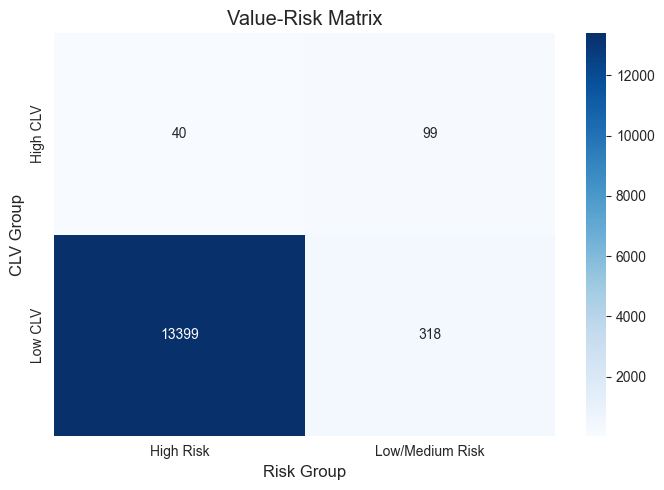

In [57]:
# 9.4 Visualize value-risk matrix

import seaborn as sns

plt.figure(figsize=(7, 5))
sns.heatmap(value_risk_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Value-Risk Matrix')
plt.xlabel('Risk Group')
plt.ylabel('CLV Group')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'value_risk_matrix_heatmap.png', dpi=300)
plt.show()

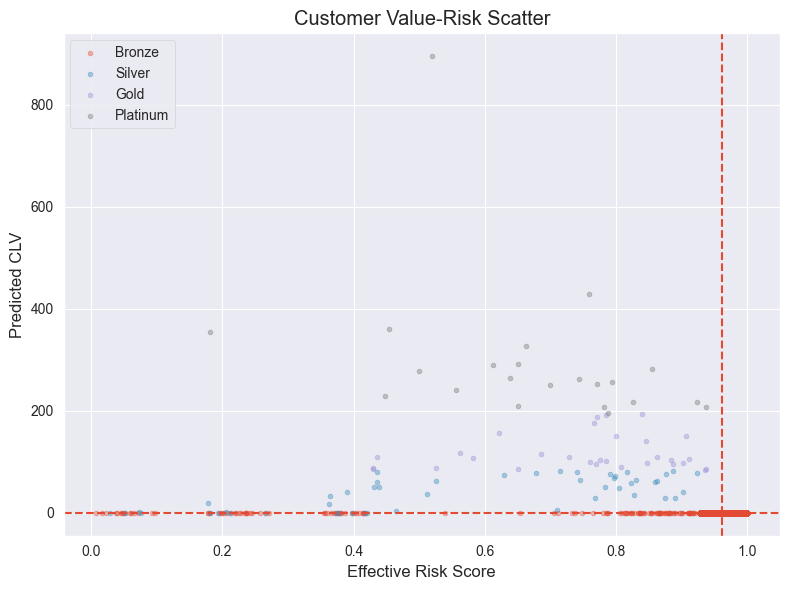

In [58]:
# 9.5 Visualize customer value vs risk

plot_df = df_model.copy()

# Sample for visualization if needed
if len(plot_df) > 5000:
    plot_df = plot_df.sample(5000, random_state=42)

plt.figure(figsize=(8, 6))
for tier in ['Bronze', 'Silver', 'Gold', 'Platinum']:
    subset = plot_df[plot_df['value_tier'] == tier]
    plt.scatter(
        subset['effective_risk_score'],
        subset['predicted_clv'],
        alpha=0.4,
        s=12,
        label=tier
    )

plt.axvline(
    df_model['effective_risk_score'].median(),
    linestyle='--'
)
plt.axhline(
    df_model['predicted_clv'].median(),
    linestyle='--'
)

plt.xlabel('Effective Risk Score')
plt.ylabel('Predicted CLV')
plt.title('Customer Value-Risk Scatter')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'value_risk_scatter.png', dpi=300)
plt.show()

In [59]:
# 9.6 Summarize strategy groups

strategy_summary = df_model.groupby('strategy_quadrant').agg({
    'customer_unique_id': 'count',
    'predicted_clv': ['mean', 'sum'],
    'future_6m_gmv': ['mean', 'sum'],
    'effective_risk_score': 'mean'
}).round(2)

strategy_summary.columns = [
    'customer_count',
    'predicted_clv_mean', 'predicted_clv_sum',
    'actual_gmv_mean', 'actual_gmv_sum',
    'risk_score_mean'
]

strategy_summary = strategy_summary.sort_values('predicted_clv_sum', ascending=False)

print("Strategy summary:")
print(strategy_summary)

strategy_summary.to_csv(
    OUTPUT_DIR/'strategy_quadrant_summary.csv'
)

Strategy summary:
                   customer_count  predicted_clv_mean  predicted_clv_sum  \
strategy_quadrant                                                          
Protect                        99              193.31           19138.14   
Retain                         40              179.96            7198.42   
Nurture                       318               11.52            3663.41   
Low Priority                13399                0.06             841.14   

                   actual_gmv_mean  actual_gmv_sum  risk_score_mean  
strategy_quadrant                                                    
Protect                     240.67        23826.25             0.66  
Retain                      208.27         8330.85             0.88  
Nurture                      16.90         5375.29             0.45  
Low Priority                  0.07          955.13             0.96  


## Value-Risk Matrix Analysis

The value-risk matrix is highly imbalanced. Most customers fall into the Low CLV and High Risk quadrant, which means the portfolio is dominated by low-value customers with weak future value.

The most important groups are `Protect` and `Retain`. Although these groups are small, they contribute much higher predicted CLV and actual GMV than the rest. `Protect` customers combine high value with relatively lower risk, while `Retain` customers are high-value but more at risk and therefore need stronger retention action.

`Nurture` customers have limited current value but still show some future potential. In contrast, `Low Priority` customers make up the largest segment but contribute very little value, so they should receive the lowest level of investment.

## 10. Marketing Budget Allocation

This section allocates marketing budget based on predicted CLV and strategy priority.

In [60]:
# 10.1 Set total budget and strategy weights

total_budget = 1_000_000

strategy_weights = {
    'Protect': 1.2,
    'Retain': 1.5,
    'Nurture': 0.8,
    'Low Priority': 0.3
}

df_model['strategy_weight'] = df_model['strategy_quadrant'].map(strategy_weights)
df_model['weighted_clv'] = df_model['predicted_clv'] * df_model['strategy_weight']

print("Strategy weights applied:")
print(df_model[['strategy_quadrant', 'strategy_weight']].drop_duplicates().sort_values('strategy_weight', ascending=False))

Strategy weights applied:
    strategy_quadrant  strategy_weight
287            Retain              1.5
95            Protect              1.2
60            Nurture              0.8
0        Low Priority              0.3


In [61]:
# 10.2 Allocate customer-level budget

weighted_total = df_model['weighted_clv'].sum()

if weighted_total == 0:
    df_model['budget_share'] = 1 / len(df_model)
else:
    df_model['budget_share'] = df_model['weighted_clv'] / weighted_total

df_model['allocated_budget'] = df_model['budget_share'] * total_budget

print("Budget allocation summary:")
print(df_model['allocated_budget'].describe())

Budget allocation summary:
count    13856.000000
mean        72.170901
std        803.159594
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      31879.538977
Name: allocated_budget, dtype: float64


In [62]:
# 10.3 Summarize budget by strategy quadrant

budget_summary = df_model.groupby('strategy_quadrant').agg({
    'customer_unique_id': 'count',
    'allocated_budget': ['sum', 'mean'],
    'predicted_clv': ['sum', 'mean'],
    'future_6m_gmv': ['sum', 'mean']
}).round(2)

budget_summary.columns = [
    'customer_count',
    'budget_sum', 'budget_mean',
    'predicted_clv_sum', 'predicted_clv_mean',
    'actual_gmv_sum', 'actual_gmv_mean'
]

budget_summary['backtest_gmv_per_budget'] = (
    budget_summary['actual_gmv_sum'] / budget_summary['budget_sum']
).replace([np.inf, -np.inf], np.nan).round(2)

budget_summary = budget_summary.sort_values('budget_sum', ascending=False)

print("Budget summary by strategy:")
print(budget_summary)

budget_summary.to_csv(
    OUTPUT_DIR/'budget_allocation_by_strategy.csv'
)

Budget summary by strategy:
                   customer_count  budget_sum  budget_mean  predicted_clv_sum  \
strategy_quadrant                                                               
Protect                        99   621595.75      6278.74           19138.14   
Retain                         40   292250.69      7306.27            7198.42   
Nurture                       318    79323.63       249.45            3663.41   
Low Priority                13399     6829.94         0.51             841.14   

                   predicted_clv_mean  actual_gmv_sum  actual_gmv_mean  \
strategy_quadrant                                                        
Protect                        193.31        23826.25           240.67   
Retain                         179.96         8330.85           208.27   
Nurture                         11.52         5375.29            16.90   
Low Priority                     0.06          955.13             0.07   

                   expected_roi  
strate

In [63]:
# 10.4 Summarize budget by value tier

budget_by_tier = df_model.groupby('value_tier').agg({
    'customer_unique_id': 'count',
    'allocated_budget': ['sum', 'mean'],
    'predicted_clv': ['sum', 'mean']
}).round(2)

budget_by_tier.columns = [
    'customer_count',
    'budget_sum', 'budget_mean',
    'predicted_clv_sum', 'predicted_clv_mean'
]

budget_by_tier = budget_by_tier.sort_values('budget_sum', ascending=False)

print("Budget summary by tier:")
print(budget_by_tier)

budget_by_tier.to_csv(
    OUTPUT_DIR/'budget_allocation_by_tier.csv'
)

Budget summary by tier:
            customer_count  budget_sum  budget_mean  predicted_clv_sum  \
value_tier                                                               
Platinum                56   578834.50     10336.33           16702.55   
Gold                    83   335011.94      4036.29            9634.01   
Silver                 137    86153.56       628.86            4504.55   
Bronze               13580        0.00         0.00               0.00   

            predicted_clv_mean  
value_tier                      
Platinum                298.26  
Gold                    116.07  
Silver                   32.88  
Bronze                    0.00  


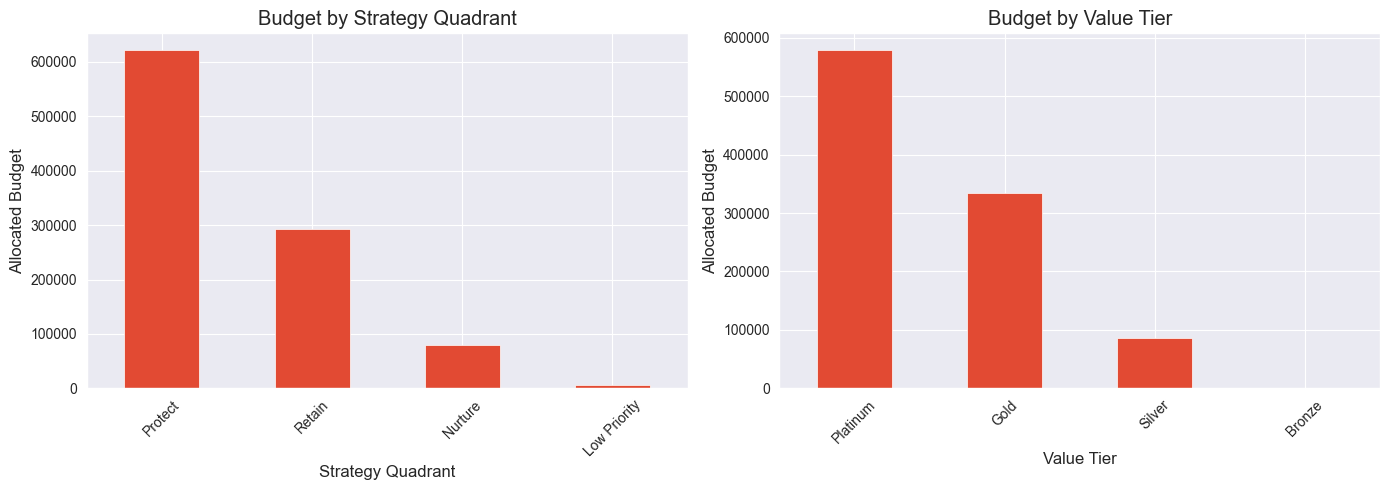

In [146]:
# 10.5 Visualize budget allocation

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

budget_summary['budget_sum'].plot(kind='bar', ax=axes[0])
axes[0].set_title('Budget by Strategy Quadrant')
axes[0].set_xlabel('Strategy Quadrant')
axes[0].set_ylabel('Allocated Budget')
axes[0].tick_params(axis='x', rotation=45)

budget_by_tier['budget_sum'].plot(kind='bar', ax=axes[1])
axes[1].set_title('Budget by Value Tier')
axes[1].set_xlabel('Value Tier')
axes[1].set_ylabel('Allocated Budget')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'budget_allocation_overview.png', dpi=300)
plt.show()

In [64]:
# 10.6 Export customer-level budget results

budget_output_cols = [
    'customer_unique_id',
    'value_tier',
    'strategy_quadrant',
    'predicted_clv',
    'effective_risk_score',
    'allocated_budget'
]

df_model[budget_output_cols].to_csv(
    OUTPUT_DIR/'customer_budget_allocation.csv',
    index=False
)

print("Customer-level budget allocation file saved.")

Customer-level budget allocation file saved.


## Marketing Budget Allocation Analysis

The budget allocation is highly concentrated in a small number of high-value customers. `Protect` and `Retain` receive most of the total budget, while `Low Priority` customers receive almost no investment.

This result is consistent with the sparse CLV structure of the dataset. Most Bronze customers have predicted CLV close to 0, so the allocation logic gives them almost no budget. Platinum and Gold tiers absorb nearly all resources, which reflects a strong value-based targeting strategy.

The ROI values should be interpreted carefully, because some groups receive very small budgets. Overall, the allocation logic is reasonable for this version: invest heavily in high-value customers, maintain limited spend on nurture groups, and minimize spend on low-priority customers.

## 11. High-Value Customer Profiling

This section profiles the highest-value customers and compares them with the rest of the customer base.

In [65]:
# 11.1 Select high-value customers

top_customers = df_model[df_model['value_tier'].isin(['Platinum', 'Gold'])].copy()

print("High-value customer count:")
print(len(top_customers))

print("\nHigh-value tier distribution:")
print(top_customers['value_tier'].value_counts())

High-value customer count:
139

High-value tier distribution:
value_tier
Gold        83
Platinum    56
Name: count, dtype: int64


In [66]:
# 11.2 Build high-value customer profile

profile_features = [
    'predicted_clv',
    'future_6m_gmv',
    'total_orders',
    'total_gmv',
    'avg_order_value',
    'monthly_frequency',
    'days_since_last_order',
    'effective_risk_score',
    'avg_review_score',
    'delay_rate'
]

high_value_profile = top_customers[profile_features].describe().T.round(2)
high_value_profile['median'] = top_customers[profile_features].median().round(2)

print("High-value customer profile:")
print(high_value_profile[['mean', 'median', 'std', 'min', 'max']])

high_value_profile.to_csv(
    OUTPUT_DIR/'high_value_customer_profile.csv'
)

High-value customer profile:
                          mean   median     std      min      max
predicted_clv           189.47   151.67  131.22    83.45   895.69
future_6m_gmv           231.35   167.81  227.83    31.75  1535.88
total_orders              2.20     2.00    0.51     2.00     6.00
total_gmv               455.63   352.35  403.51   154.59  3559.99
avg_order_value         209.50   166.78  186.52    53.19  1780.00
monthly_frequency         0.60     0.43    0.51     0.15     3.75
days_since_last_order  3117.14  3120.00   55.87  2923.00  3200.00
effective_risk_score      0.73     0.77    0.15     0.18     0.95
avg_review_score          4.30     5.00    0.98     1.00     5.00
delay_rate                0.07     0.00    0.18     0.00     1.00


In [67]:
# 11.3 Compare high-value customers with others

other_customers = df_model[~df_model['customer_unique_id'].isin(top_customers['customer_unique_id'])].copy()

comparison = pd.DataFrame({
    'High_Value': top_customers[profile_features].mean(),
    'Others': other_customers[profile_features].mean()
}).round(2)

comparison['Difference'] = (comparison['High_Value'] - comparison['Others']).round(2)

print("High-value vs others:")
print(comparison)

comparison.to_csv(
    OUTPUT_DIR/'high_value_vs_others.csv'
)

High-value vs others:
                       High_Value   Others  Difference
predicted_clv              189.47     0.33      189.14
future_6m_gmv              231.35     0.46      230.89
total_orders                 2.20     1.05        1.15
total_gmv                  455.63   168.66      286.97
avg_order_value            209.50   162.57       46.93
monthly_frequency            0.60    29.62      -29.02
days_since_last_order     3117.14  3270.99     -153.85
effective_risk_score         0.73     0.95       -0.22
avg_review_score             4.30     4.20        0.10
delay_rate                   0.07     0.05        0.02


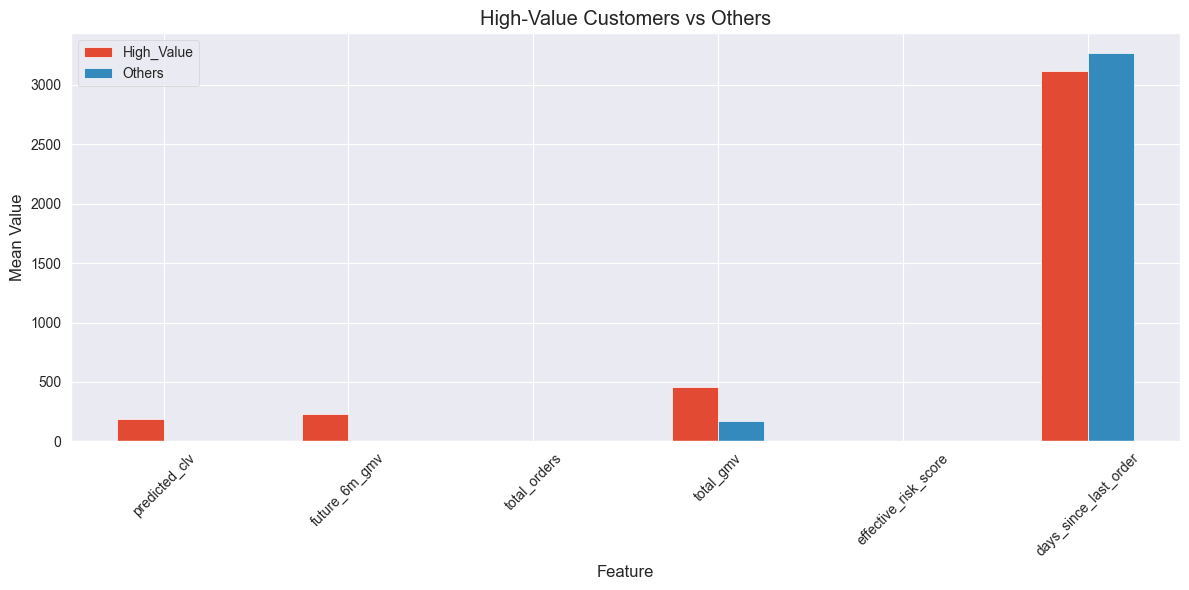

In [68]:
# 11.4 Visualize profile comparison

plot_features = [
    'predicted_clv',
    'future_6m_gmv',
    'total_orders',
    'total_gmv',
    'effective_risk_score',
    'days_since_last_order'
]

comparison_plot = comparison.loc[plot_features, ['High_Value', 'Others']]

comparison_plot.plot(kind='bar', figsize=(12, 6))
plt.title('High-Value Customers vs Others')
plt.xlabel('Feature')
plt.ylabel('Mean Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'high_value_vs_others.png', dpi=300)
plt.show()

In [69]:
# 11.5 Export high-value customer list

high_value_output_cols = [
    'customer_unique_id',
    'value_tier',
    'predicted_clv',
    'future_6m_gmv',
    'effective_risk_score',
    'effective_risk_level',
    'strategy_quadrant',
    'allocated_budget'
]

top_customers[high_value_output_cols].to_csv(
    OUTPUT_DIR/'high_value_customers.csv',
    index=False
)

print("High-value customer file saved.")

High-value customer file saved.


## High-Value Customer Profiling Analysis and Summary

A total of 139 customers are identified as high-value customers, including 83 Gold customers and 56 Platinum customers. This confirms that the high-value segment is very small relative to the full customer base, which is consistent with the strong concentration pattern found earlier in the CLV analysis.

Compared with other customers, high-value customers show much stronger value-related behavior. Their average predicted CLV is 189.47 versus 0.33 for others, and their average actual future GMV is 231.35 versus 0.46. They also have more orders, higher historical GMV, and higher average order value, which suggests that both purchase scale and spending power are important characteristics of the top-value segment.

In terms of customer quality, high-value customers appear more recent and less risky. Their average `days_since_last_order` is lower, which means they are more recently active, and their average `effective_risk_score` is also lower than the rest of the customer base. Review scores are slightly higher as well, indicating that high-value customers are not only more valuable but also relatively healthier customers overall.

One metric should be interpreted carefully: `monthly_frequency` is unexpectedly lower for the high-value group than for other customers. This is not fully consistent with the rest of the profile and may be affected by the current frequency calculation method or extreme values in the denominator. Therefore, this feature should be reviewed again before drawing a strong business conclusion from it.

## 12. Validation and Tier Accuracy

This section evaluates how well the predicted CLV tiers match the actual future GMV tiers.

In [70]:
# 12.1 Create actual value tiers from future GMV (holdout only)

df_test_eval['actual_value_tier'] = 'Bronze'

positive_actual_mask = df_test_eval['future_6m_gmv'] > 0
df_actual_positive = df_test_eval.loc[
    positive_actual_mask,
    ['customer_unique_id', 'future_6m_gmv']
].copy()

if len(df_actual_positive) > 0:
    df_actual_positive['actual_percentile'] = df_actual_positive['future_6m_gmv'].rank(
        method='first',
        pct=True
    )

    def assign_actual_tier(percentile):
        if percentile >= 0.80:
            return 'Platinum'
        elif percentile >= 0.50:
            return 'Gold'
        else:
            return 'Silver'

    df_actual_positive['actual_value_tier'] = df_actual_positive['actual_percentile'].apply(
        assign_actual_tier
    )

    df_test_eval = df_test_eval.drop(columns=['actual_value_tier'], errors='ignore').merge(
        df_actual_positive[['customer_unique_id', 'actual_value_tier']],
        on='customer_unique_id',
        how='left'
    )

    df_test_eval['actual_value_tier'] = df_test_eval['actual_value_tier'].fillna('Bronze')

print("Actual tier distribution:")
print(df_test_eval['actual_value_tier'].value_counts())

Actual tier distribution:
actual_value_tier
Bronze      13635
Silver        110
Gold           66
Platinum       45
Name: count, dtype: int64


In [71]:
# 12.2 Build tier confusion matrix

from sklearn.metrics import confusion_matrix

tier_order = ['Bronze', 'Silver', 'Gold', 'Platinum']

cm = confusion_matrix(
    df_test_eval['actual_value_tier'],
    df_test_eval['value_tier'],
    labels=tier_order
)

cm_df = pd.DataFrame(
    cm,
    index=[f'Actual_{t}' for t in tier_order],
    columns=[f'Pred_{t}' for t in tier_order]
)

print("Tier confusion matrix:")
print(cm_df)

Tier confusion matrix:
                 Pred_Bronze  Pred_Silver  Pred_Gold  Pred_Platinum
Actual_Bronze          13580           55          0              0
Actual_Silver              0           74         34              2
Actual_Gold                0            6         45             15
Actual_Platinum            0            2          4             39


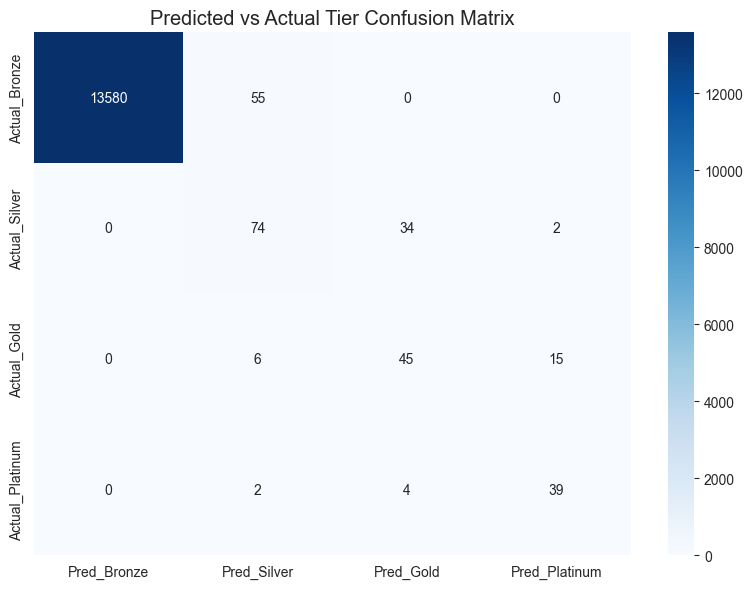

In [72]:
# 12.3 Visualize tier confusion matrix

import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_df,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title('Predicted vs Actual Tier Confusion Matrix')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'tier_confusion_matrix.png', dpi=300)
plt.show()

In [73]:
# 12.4 Classification report by tier

from sklearn.metrics import classification_report

tier_report = classification_report(
    df_test_eval['actual_value_tier'],
    df_test_eval['value_tier'],
    labels=tier_order,
    output_dict=True,
    zero_division=0
)

tier_report_df = pd.DataFrame(tier_report).T.round(4)

print("Tier classification report:")
print(tier_report_df)

tier_report_df.to_csv(
    OUTPUT_DIR/'tier_classification_report.csv'
)

Tier classification report:
              precision  recall  f1-score     support
Bronze           1.0000  0.9960    0.9980  13635.0000
Silver           0.5401  0.6727    0.5992    110.0000
Gold             0.5422  0.6818    0.6040     66.0000
Platinum         0.6964  0.8667    0.7723     45.0000
accuracy         0.9915  0.9915    0.9915      0.9915
macro avg        0.6947  0.8043    0.7434  13856.0000
weighted avg     0.9932  0.9915    0.9922  13856.0000


In [74]:
# 12.5 Evaluate top-customer identification

df_test_eval['is_top_actual'] = df_test_eval['actual_value_tier'].isin(['Platinum', 'Gold']).astype(int)
df_test_eval['is_top_predicted'] = df_test_eval['value_tier'].isin(['Platinum', 'Gold']).astype(int)

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

top_precision = precision_score(df_test_eval['is_top_actual'], df_test_eval['is_top_predicted'], zero_division=0)
top_recall = recall_score(df_test_eval['is_top_actual'], df_test_eval['is_top_predicted'], zero_division=0)
top_f1 = f1_score(df_test_eval['is_top_actual'], df_test_eval['is_top_predicted'], zero_division=0)
top_accuracy = accuracy_score(df_test_eval['is_top_actual'], df_test_eval['is_top_predicted'])

print("Top-customer identification metrics:")
print(f"Precision: {top_precision:.4f}")
print(f"Recall:    {top_recall:.4f}")
print(f"F1-score:  {top_f1:.4f}")
print(f"Accuracy:  {top_accuracy:.4f}")

Top-customer identification metrics:
Precision: 0.7410
Recall:    0.9279
F1-score:  0.8240
Accuracy:  0.9968


In [75]:
# 12.6 Export validation results

validation_output_cols = [
    'customer_unique_id',
    'predicted_clv',
    'future_6m_gmv',
    'value_tier',
    'actual_value_tier',
    'is_top_predicted',
    'is_top_actual'
]

df_test_eval[validation_output_cols].to_csv(
    OUTPUT_DIR/'tier_validation_results.csv',
    index=False
)

print("Validation file saved.")

Validation file saved.


## Validation and Tier Accuracy Analysis and Summary

The validation results show that the predicted tier structure is broadly aligned with the actual future GMV tiers. Most Bronze customers are classified correctly, and the confusion matrix also shows a relatively clear diagonal pattern for Silver, Gold, and Platinum.

Tier performance is strongest for Bronze and Platinum. Bronze has near-perfect precision and recall because the low-value majority is captured very well. Platinum also performs relatively well, with the highest F1-score among the non-Bronze tiers. Silver and Gold are more difficult to separate, and some confusion remains between adjacent tiers, which is reasonable given that their value ranges are closer.

The top-customer identification result is strong. The model achieves precision of 0.7410, recall of 0.9279, and F1-score of 0.8240. This means the model is especially effective at finding most high-value customers, although it still includes some false positives. Overall, the validation step suggests that the tiering framework is reliable enough for practical segmentation and downstream business use.

## 13. Business Insights and Final Summary

This section summarizes the main findings and exports the final CLV outputs.

In [77]:
# 13.1 Build key metrics summary

top_feature_names = feature_importance.head(5)['feature'].tolist()

final_metrics = {
    'best_model': best_model_name,
    'rmse_log': float(results_df.iloc[0]['RMSE_log']),
    'r2_log': float(results_df.iloc[0]['R2_log']),
    'mae_raw': float(results_df.iloc[0]['MAE_raw']),
    'rmse_raw': float(results_df.iloc[0]['RMSE_raw']),
    'top_customer_precision': float(top_precision),
    'top_customer_recall': float(top_recall),
    'top_customer_f1': float(top_f1),
    'high_value_customer_count':int(df_model['value_tier'].isin(['Platinum', 'Gold']).sum()),
    'top_5_features': ', '.join(top_feature_names)
}

final_metrics_df = pd.DataFrame(
    list(final_metrics.items()),
    columns=['metric', 'value']
)

print("Final metrics summary:")
print(final_metrics_df)

final_metrics_df.to_csv(
    OUTPUT_DIR / 'final_metrics_summary.csv',
    index=False
)

Final metrics summary:
                      metric  \
0                 best_model   
1                   rmse_log   
2                     r2_log   
3                    mae_raw   
4                   rmse_raw   
5     top_customer_precision   
6        top_customer_recall   
7            top_customer_f1   
8  high_value_customer_count   
9             top_5_features   

                                               value  
0                                      Random Forest  
1                                           0.110384  
2                                           0.971683  
3                                           1.155504  
4                                          13.820099  
5                                           0.741007  
6                                           0.927928  
7                                              0.824  
8                                                139  
9  recency_score, days_since_last_order, total_or...  


In [82]:
# 13.2 Generate business insights text

top10_n = max(1, int(len(df_model) * 0.10))
top10_customers = df_model.nlargest(top10_n, 'predicted_clv')

total_actual_gmv = df_model['future_6m_gmv'].sum()
if total_actual_gmv > 0:
    top10_gmv_contribution = top10_customers['future_6m_gmv'].sum() / total_actual_gmv
else:
    top10_gmv_contribution = 0.0

platinum_avg_clv = tier_stats.loc['Platinum', 'predicted_clv_mean'] if 'Platinum' in tier_stats.index else 0.0
bronze_avg_clv = tier_stats.loc['Bronze', 'predicted_clv_mean'] if 'Bronze' in tier_stats.index else 0.0

top5_feature_lines = '\n'.join(
    [f"- {row['feature']}: {row['importance']:.4f}" for _, row in feature_importance.head(5).iterrows()]
)

platinum_budget_per_customer = (
    budget_by_tier.loc['Platinum', 'budget_mean'] if 'Platinum' in budget_by_tier.index else 0.0
)

platinum_expected_roi = 0.0
if 'Platinum' in budget_by_tier.index and budget_by_tier.loc['Platinum', 'budget_sum'] > 0:
    platinum_expected_roi = (
        budget_by_tier.loc['Platinum', 'predicted_clv_sum'] /
        budget_by_tier.loc['Platinum', 'budget_sum']
    )

insights_text = f"""
# CLV Prediction Project - Business Insights

## 1. Model Performance
- Best model: {best_model_name}
- RMSE on log target: {results_df.iloc[0]['RMSE_log']:.4f}
- R² on log target: {results_df.iloc[0]['R2_log']:.4f}
- MAE on raw target: {results_df.iloc[0]['MAE_raw']:.4f}
- RMSE on raw target: {results_df.iloc[0]['RMSE_raw']:.4f}

## 2. Customer Value Distribution
- Top 10% customer contribution: {top10_gmv_contribution:.2%} of total future GMV
- Platinum average predicted CLV: {platinum_avg_clv:.2f}
- Bronze average predicted CLV: {bronze_avg_clv:.2f}

## 3. Top 5 Predictive Factors
{top5_feature_lines}

## 4. Value-Risk Findings
{strategy_summary.to_string()}

## 5. Marketing Budget Suggestions
- Platinum budget per customer: {platinum_budget_per_customer:.2f}
- Platinum expected ROI: {platinum_expected_roi:.2f}x

## 6. Business Actions
1. Focus on high-value customers with VIP-style retention and service.
2. Apply differentiated marketing by customer value tier.
3. Prioritize urgent retention for high-value high-risk customers.
4. Develop uplift strategies for lower-value but promising customers.
5. Evaluate acquisition efficiency with a CLV-to-CAC logic.
"""

print(insights_text)

with open(OUTPUT_DIR / 'business_insights.md', 'w', encoding='utf-8') as f:
    f.write(insights_text)


# CLV Prediction Project - Business Insights

## 1. Model Performance
- Best model: Random Forest
- RMSE on log target: 0.1104
- R² on log target: 0.9717
- MAE on raw target: 1.1555
- RMSE on raw target: 13.8201

## 2. Customer Value Distribution
- Top 10% customer contribution: 100.00% of total future GMV
- Platinum average predicted CLV: 298.26
- Bronze average predicted CLV: 0.00

## 3. Top 5 Predictive Factors
- recency_score: 0.5270
- days_since_last_order: 0.3673
- total_orders: 0.0297
- total_gmv: 0.0177
- effective_risk_score: 0.0169

## 4. Value-Risk Findings
                   customer_count  predicted_clv_mean  predicted_clv_sum  actual_gmv_mean  actual_gmv_sum  risk_score_mean
strategy_quadrant                                                                                                         
Protect                        99              193.31           19138.14           240.67        23826.25             0.66
Retain                         40              179.96  

In [80]:
# 13.3 Export final full results

final_output_cols = [
    'customer_unique_id',
    'future_6m_gmv',
    'predicted_clv',
    'value_tier',
    'actual_value_tier',
    'clv_group',
    'risk_group',
    'strategy_quadrant',
    'effective_risk_score',
    'effective_risk_level',
    'allocated_budget',
    'is_top_predicted',
    'is_top_actual'
]

optional_cols = [
    'R_score', 'F_score', 'M_score', 'rfm_score',
    'total_orders', 'total_gmv', 'avg_order_value',
    'monthly_frequency', 'days_since_last_order',
    'value_potential', 'recency_score', 'customer_maturity'
]

final_export_cols = final_output_cols + [
    col for col in optional_cols if col in df_model.columns
]

df_model[final_export_cols].to_csv(
    OUTPUT_DIR / 'clv_prediction_full_results.csv',
    index=False
)

print("Full results file saved.")

Full results file saved.


In [81]:
# 13.3 Export final full results

final_output_cols = [
    'customer_unique_id',
    'future_6m_gmv',
    'predicted_clv',
    'value_tier',
    'actual_value_tier',
    'clv_group',
    'risk_group',
    'strategy_quadrant',
    'effective_risk_score',
    'effective_risk_level',
    'allocated_budget',
    'is_top_predicted',
    'is_top_actual'
]

optional_cols = [
    'R_score', 'F_score', 'M_score', 'rfm_score',
    'total_orders', 'total_gmv', 'avg_order_value',
    'monthly_frequency', 'days_since_last_order',
    'value_potential', 'recency_score', 'customer_maturity'
]

final_export_cols = final_output_cols + [
    col for col in optional_cols if col in df_model.columns
]

df_model[final_export_cols].to_csv(
    OUTPUT_DIR / 'clv_prediction_full_results.csv',
    index=False
)

print("Full results file saved.")

Full results file saved.


## Analysis and Summary

The final CLV workflow is complete. The project produces customer-level CLV predictions, customer tiers, value-risk segmentation, budget allocation outputs, and validation results.

The results show a highly concentrated value structure, where a small number of customers contribute most of the future value. Random Forest is the best-performing model, and recency-related features are the strongest predictors in this version.

From a business perspective, the project supports a clear action framework: protect stable high-value customers, retain high-value risky customers, nurture smaller growth groups, and reduce spending on low-priority customers.

# CLV Prediction Project - Business Insights

## 1. Model Performance
- Best model: Random Forest
- RMSE (log): 0.1104
- R² (log): 0.9717
- MAE (raw): 1.1555
- RMSE (raw): 13.8201

## 2. Customer Value Structure
- Customer value is highly concentrated.
- Most customers are in the low-value segment.
- A small group contributes most future GMV.

## 3. Key Predictive Signals
- Top features: recency_score, days_since_last_order, total_orders, total_gmv, effective_risk_score
- Recency is the strongest CLV signal.

## 4. Value-Risk Findings
- Protect and Retain are the most important groups.
- Low Priority contains most customers but contributes little value.

## 5. Budget Allocation
- Budget is concentrated in Platinum and Gold customers.
- Protect and Retain receive most of the budget.

## 6. Validation
- Precision: 0.7410
- Recall: 0.9279
- F1-score: 0.8240

## 7. Business Actions
1. Retain high-value risky customers.
2. Protect stable high-value customers.
3. Limit spend on low-value high-risk customers.
4. Track recency signals in future CLV updates.

In [83]:
# 13.5 Consolidate and clean outputs

from pathlib import Path
import shutil
import os

CURRENT_NOTEBOOK_DIR = Path.cwd()
LEGACY_OUTPUT_DIR = CURRENT_NOTEBOOK_DIR / 'output' / '07_clv_prediction'
FINAL_OUTPUT_DIR = CURRENT_NOTEBOOK_DIR.parent / 'output' / '07_clv_prediction'

FINAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

keep_files = {
    'final_metrics_summary.csv',
    'business_insights.md',
    'clv_prediction_full_results.csv',
    'model_comparison_log_target.csv',
    'model_comparison_log_target.png',
    'feature_importance_rf.csv',
    'feature_importance_top15_rf.png',
    'customer_value_tiers.csv',
    'customer_tier_statistics.csv',
    'customer_tier_overview.png',
    'strategy_quadrant_summary.csv',
    'value_risk_matrix_heatmap.png',
    'budget_allocation_by_strategy.csv',
    'budget_allocation_by_tier.csv',
    'budget_allocation_overview.png',
    'high_value_customers.csv',
    'high_value_customer_profile.csv',
    'tier_classification_report.csv',
    'tier_confusion_matrix.png'
}

# Move legacy files from Statistical_analysis_report/output/07_clv_prediction
if LEGACY_OUTPUT_DIR.exists() and LEGACY_OUTPUT_DIR.resolve() != FINAL_OUTPUT_DIR.resolve():
    for file_path in LEGACY_OUTPUT_DIR.iterdir():
        if file_path.is_file():
            target_path = FINAL_OUTPUT_DIR / file_path.name
            if target_path.exists():
                file_path.unlink()
            else:
                shutil.move(str(file_path), str(target_path))

# Remove files not in keep list
removed_files = []
for file_path in FINAL_OUTPUT_DIR.iterdir():
    if file_path.is_file() and file_path.name not in keep_files:
        file_path.unlink()
        removed_files.append(file_path.name)

# Remove empty legacy directory if possible
if LEGACY_OUTPUT_DIR.exists() and LEGACY_OUTPUT_DIR.resolve() != FINAL_OUTPUT_DIR.resolve():
    try:
        LEGACY_OUTPUT_DIR.rmdir()
        legacy_removed = True
    except OSError:
        legacy_removed = False
else:
    legacy_removed = False

print("Final output directory:")
print(FINAL_OUTPUT_DIR)

print("\nKept files:")
for name in sorted([f.name for f in FINAL_OUTPUT_DIR.iterdir() if f.is_file()]):
    print("-", name)

print("\nRemoved files:")
for name in sorted(removed_files):
    print("-", name)

print("\nLegacy output directory removed:", legacy_removed)

Final output directory:
C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\07_clv_prediction

Kept files:
- budget_allocation_by_strategy.csv
- business_insights.md
- clv_prediction_full_results.csv
- customer_tier_overview.png
- feature_importance_rf.csv
- feature_importance_top15_rf.png
- final_metrics_summary.csv
- high_value_customers.csv
- model_comparison_log_target.csv
- model_comparison_log_target.png
- strategy_quadrant_summary.csv
- tier_classification_report.csv
- tier_confusion_matrix.png
- value_risk_matrix_heatmap.png

Removed files:

Legacy output directory removed: False
